# EurekAlert–DOI/Paper Matching Analysis

 This notebook contains the main analysis and summary results for matching EurekAlert press releases to external research paper metadata using the waterfall pipeline.  
 
 **Contents:**
 - Dataset and pipeline overview
 - Scope detection (organization/journal-to-entity mapping)
 - Matching passes (DOI, title, heuristic, etc.)
 - Result summaries and match rates
 - Interpretation, caveats, and downstream guidance

 _For methodology, refer to `MatchingPlan.md`. For pipeline code, see `code/matching_pipeline.py`._

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path(".").resolve()))

from eurekalert_duckdb import setup_views

# Initialize DuckDB connection and (re)build scope tables + pr_* views
con = duckdb.connect("../Processed/eurekalert.duckdb")
setup_views(con)

# All DOIs from the DOI list
doilist = con.sql("SELECT *, lower(trim(doi)) AS doi_norm FROM doi_list")

# All press releases from 2015 onward where we have a DOI or DOI for text or Article Title
pr_base = con.sql("SELECT * FROM pr_base")

# New columns added to pr_base
# cleaned_doi: standardize the DOI column
# doi_from_pr: DOI from the press release text or summary
# final_doi: coalesce the cleaned_doi and doi_from_pr

In [2]:
len(pr_base), len(doilist)

(376607, 1554996)

In [3]:
con.sql('''select match_method, count(*) from pr_paper_matched group by match_method limit 10''')

┌────────────────────────┬──────────────┐
│      match_method      │ count_star() │
│        varchar         │    int64     │
├────────────────────────┼──────────────┤
│ doi                    │        14170 │
│ exact_title            │          235 │
│ scope_name_text_search │        22253 │
└────────────────────────┴──────────────┘

In [ ]:
con.sql("""
    SELECT pr_base.Type, COUNT(*) AS n
    FROM pr_base
    JOIN doi_list ON pr_base.cleaned_doi = doi_list.doi
    GROUP BY pr_base.Type
    ORDER BY n DESC
""").df()

In [ ]:
con.sql("""
select "Primary keyword", count(*) as n from pr_base group by "Primary keyword" order by n desc
""").df()

## Matching DOIs to unmatched PRs (7,282 scope-only)

These PRs have an entity from `scope_name_text_search` but no DOI yet. **Do not join them to the full `doi_list` (~1.2M rows)** — that explodes to hundreds of millions of pairs for large entities.

**Strategy (see `title_fuzzy_match.py`):**
1. **Scope** — only papers from the same `entity_name` as the PR
2. **Block** — inverted word index on paper titles; rare words only (length ≥ 5, not stopwords, ≤ 80 DOIs per entity)
3. **Filter** — publication date within 348 days (99th percentile from matched PRs)
4. **Score** — Jaro-Winkler + token recall on the small candidate set only

In [ ]:
from matching_pipeline import setup, match_doi, match_title, scope_only, build_final

setup(con)
match_doi(con)
match_title(con)
scope_only(con)
build_final(con)

# Naive entity join size (why a direct join is too slow)
con.sql("""
    WITH um AS (
        SELECT entity_name, count(*) AS pr_count
        FROM pr_paper_matched WHERE is_matched = 0
        GROUP BY entity_name
    ),
    dl AS (
        SELECT entity_name, count(*) AS doi_count
        FROM doi_list GROUP BY entity_name
    )
    SELECT
        sum(um.pr_count) AS unmatched_prs,
        sum(um.pr_count * dl.doi_count) AS naive_entity_join_pairs
    FROM um
    JOIN dl ON um.entity_name = dl.entity_name
""").df()

In [ ]:
# Get the range of actual publication date on doi_list to compare with pr_base.pub_date
pub_date_diff = con.sql('''
select cleaned_doi as doi, pub_date as pr_pub_date, publication_date as doi_pub_date, 
abs(pub_date - publication_date) as days_diff
from pr_base pb
inner join doi_list_norm dln on pb.cleaned_doi = dln.doi
where pb.pub_date is not null and dln.publication_date is not null
order by days_diff desc
''').df()

pub_date_diff.head(10)

In [ ]:
# Get the 95th percentile of the days difference
pub_date_diff['days_diff'].quantile(0.99)

In [ ]:
unmatched_prs = con.sql('''
select a.*, b.Headline as pr_heading, b.summary as pr_summary, b."Full Text" as pr_full_text, dln.doi, dln.title as dln_title
from (select * from pr_paper_matched where is_matched = 0) a
inner join pr_base b on a."pr_id" = b."PR ID"
inner join doi_list_norm dln on a.entity_name = dln.entity_name
where 
    abs(b.pub_date - dln.publication_date) < 348
    or (
        b.Headline is not null and dln.title is not null
        and exists (
            select 1
            from unnest(string_to_array(regexp_replace(b.Headline, '[^a-zA-Z0-9 ]', '', 'g'), ' ')) as u(word)
            where word <> '' and position(lower(word) in lower(dln.title)) > 0
        )
    )
''')

In [ ]:
con.sql('''
select * from doi_list_norm limit 10
''').df()

## Embedding match

Entity scope comes from `scope_name_text_search` (same as `pr_paper_matched.entity_name`). Embeddings pick the best DOI title within that entity.

In [2]:
from embedding_match import run_embedding_match

n = run_embedding_match(con, min_sim=0.7, max_days=348, rebuild=False)
n

d:\gaTech\EuerkAlertWork\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 2232/2232 [54:34<00:00,  1.47s/it] 


1174

In [3]:
con.sql('''
select count(*) from embedding_title_match limit 10
''').df()

,count_star()
0,1174


In [4]:
con.sql("""
    SELECT round(avg(embedding_sim), 3) AS avg_sim,
           count(*) AS n,
           count(distinct pr_id) AS prs
    FROM embedding_title_match
""").df()

,avg_sim,n,prs
0,0.797,1174,1174


In [5]:
test_df = con.sql("""
    SELECT pr_id, matched_doi, embedding_sim,
           (pr_text) AS pr_text,
           (paper_title) AS paper_title
    FROM embedding_title_match
    ORDER BY embedding_sim desc
""").df()

In [6]:
len(test_df)

1174

In [85]:
test_df.to_csv('result.csv')

In [10]:
test_df[test_df['embedding_sim'] > 0.7]

,pr_id,matched_doi,embedding_sim,pr_text,paper_title
0,1035294,10.1007/s11426-023-1753-5,1.000000,Tailoring morphology symmetry of bismuth vanad...,Tailoring morphology symmetry of bismuth vanad...
1,986606,10.1016/s1872-2067(22)64195-0,1.000000,Bioconversion of methanol to 3-hydroxypropiona...,Bioconversion of methanol to 3-hydroxypropiona...
2,1053985,10.1007/s11704-024-41999-y,1.000000,Announcement of the 2024 FCS Paper Awards,Announcement of the 2024 FCS Paper Awards
3,476998,10.1103/physrevlett.125.030506,1.000000,Experimental optimal verification of entangled...,Experimental Optimal Verification of Entangled...
4,932117,10.1016/s1872-2067(21)63836-6,1.000000,Amide-linked covalent organic frameworks as ef...,Amide-linked covalent organic frameworks as ef...
...,...,...,...,...,...
503,947816,10.1039/d1cp04303j,0.700698,A strategy for efficient p-doping in Al-rich A...,Regulating the valence level arrangement of hi...
504,969396,10.1002/cac2.12457,0.700600,"New insights into biology, origin of deadly st...",Worldwide trends in esophageal cancer survival...
505,1000415,10.3390/photonics11010001,0.700426,Infrared avalanche photodiodes from bulk to 2D...,Research on the Structure Design of Silicon Av...
506,1002696,10.1002/cac2.12576,0.700388,Combination radiation with immunotherapy shows...,Beyond success: unveiling the hidden potential...


In [30]:
con.sql('''select * from unmatched_pr_scope''')

┌─────────┬─────────────────────────────────────────────────────────────────────────────────────────┬────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  pr_id  │                                       entity_name                                       │  pub_date  │                                                             pr_text                                                             │
│ varchar │                                         varchar                                         │    date    │                                                             varchar                                                             │
├─────────┼─────────────────────────────────────────────────────────────────────────────────────────┼────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ 917374  │ Cancer C

In [42]:
x = con.sql('''select "Article Title", "Summary", "Headline" from pr_base where "PR ID" = 1055673
''').df()

In [44]:
x['Summary']

0    Synthetic immunology, an innovative field of r...
Name: Summary, dtype: str

In [65]:
x

,Article Title,Summary,Headline
0,Bottom-up synthetic immunology.,"Synthetic immunology, an innovative field of r...",Synthetic immunology: Approaching a turning po...


In [48]:
con.sql('''desc doi_list_norm''')

┌──────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│   column_name    │ column_type │  null   │   key   │ default │  extra  │
│     varchar      │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ entity_name      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ openalex_id      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ category         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ doi              │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ publication_date │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ title            │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ doi_norm         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
└──────────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [60]:
query = "select * from doi_list_norm where doi = '10.1002/cac2.12579'"
y = con.sql(query).df()

In [61]:
str(y['title'])

'0    “Find Me” and “Eat Me” signals: tools to drive...\nName: title, dtype: str'

In [ ]:
print(y["title"].iloc[0])


“Find Me” and “Eat Me” signals: tools to drive phagocytic processes for modulating antitumor immunit


In [81]:
len((test_df["pr_text"].iloc[12]))


60

In [82]:
for i in range(10859):
    if len((test_df["pr_text"].iloc[i])) >= 61:
        print(i)


## Press release matching coverage

In [3]:
query = '''
select * from pr_paper_matched
'''
press_release_data = con.sql(query).df()

In [9]:
query = '''
WITH name_variations AS (
  SELECT * FROM (VALUES
  ('journal', 'Advanced Devices & Instrumentation', 'Adv Devices Instrum'),
  ('journal', 'Advanced Devices & Instrumentation', 'Advanced Devices and Instrumentation'),
  ('journal', 'Advanced Devices & Instrumentation', 'Advanced Devices & Instrumentation'),
  ('journal', 'Energy Material Advances', 'Energy Material Advances'),
  ('journal', 'Energy Material Advances', 'Energy Materials Advances'),
  ('journal', 'Energy Material Advances', 'Energy Material Adv'),
  ('journal', 'Space: Science & Technology', 'Space: Science & Technology'),
  ('journal', 'Space: Science & Technology', 'Space: Science and Technology'),
  ('journal', 'Space: Science & Technology', 'Space Sci Technol'),
  ('journal', 'Space: Science & Technology', 'Space Science & Technology'),
  ('journal', 'Space: Science & Technology', 'Space Science and Technology'),
  ('journal', 'Cyborg and Bionic Systems', 'Cyborg Bionic Systems'),
  ('journal', 'Cyborg and Bionic Systems', 'Cyborg & Bionic Systems'),
  ('journal', 'Cyborg and Bionic Systems', 'Cyborg and Bionic Systems'),
  ('journal', 'BioDesign Research', 'BioDesign Research'),
  ('journal', 'BioDesign Research', 'BioDesign Res'),
  ('journal', 'BioDesign Research', 'Bio-Design Research'),
  ('journal', 'BioDesign Research', 'Bio Design Research'),
  ('journal', 'Biomaterials Research', 'Biomaterials Res'),
  ('journal', 'Biomaterials Research', 'Biomaterials Research'),
  ('journal', 'BMEF (BME Frontiers)', 'BMEF (BME Frontiers)'),
  ('journal', 'BMEF (BME Frontiers)', 'BME Frontiers'),
  ('journal', 'BMEF (BME Frontiers)', 'BMEF'),
  ('journal', 'Ecosystem Health and Sustainability', 'Ecosystem Health and Sustainability'),
  ('journal', 'Ecosystem Health and Sustainability', 'Ecosystem Health Sustain'),
  ('journal', 'Ecosystem Health and Sustainability', 'Ecosystem Health & Sustainability'),
  ('journal', 'Health Data Science', 'Health Data Sci'),
  ('journal', 'Health Data Science', 'Health Data Science'),
  ('journal', 'Intelligent Computing', 'Intell Computing'),
  ('journal', 'Intelligent Computing', 'Intelligent Comput'),
  ('journal', 'Intelligent Computing', 'Intelligent Computing'),
  ('journal', 'Journal of Bio-X Research', 'Journal of Bio-X Research'),
  ('journal', 'Journal of Bio-X Research', 'Bio X Research'),
  ('journal', 'Journal of Bio-X Research', 'J Bio-X Res'),
  ('journal', 'Journal of Bio-X Research', 'Bio-X Research'),
  ('journal', 'Journal of Bio-X Research', 'Journal of Bio X Research'),
  ('journal', 'Journal of Remote Sensing', 'Journal of Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'J Remote Sens'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean-Land-Atmosphere Research'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean Land Atmosphere Research'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean-Land-Atmosphere Research (OLAR)'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean-Land-Atmosphere Res'),
  ('journal', 'Plant Phenomics', 'Plant Phenomics journal'),
  ('journal', 'Plant Phenomics', 'Plant Phenomics'),
  ('journal', 'Research', 'Science Partner Journal Research'),
  ('journal', 'Ultrafast Science', 'Ultrafast Sci'),
  ('journal', 'Ultrafast Science', 'Ultrafast Science'),
  ('journal', 'Journal of EMDR Practice and Research', 'J EMDR Pract Res'),
  ('journal', 'Journal of EMDR Practice and Research', 'Journal of EMDR Practice & Research'),
  ('journal', 'Journal of EMDR Practice and Research', 'Journal of EMDR Practice and Research'),
  ('journal', 'Journal of EMDR Practice and Research', 'EMDR Practice and Research'),
  ('institution', 'Science Partner Journals', 'Science Partner Journals (SPJ)'),
  ('institution', 'Science Partner Journals', 'AAAS Science Partner Journals'),
  ('institution', 'Science Partner Journals', 'Science Partner Journals'),
  ('institution', 'Science Partner Journals', 'Science Partner Journal'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'Beijing Institute of Technology Press Co., Ltd'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'Beijing Inst of Technology Press'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'Beijing Institute of Technology Press'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'BIT Press'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'Beijing Institute of Technology Press Co Ltd'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'Chinese Academy of Sciences (CAS)'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'The Chinese Academy of Sciences'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'CAS Headquarters'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'Chinese Academy of Science'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'Chinese Academy of Sciences Headquarters'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'Chinese Academy of Sciences'),
  ('institution', 'University of Science and Technology of China', 'Univ of Sci and Tech of China'),
  ('institution', 'University of Science and Technology of China', 'University of Science and Technology of China'),
  ('institution', 'University of Science and Technology of China', 'Univ. of Science and Technology of China'),
  ('institution', 'Institute of Physics, Chinese Academy of Sciences', 'Institute of Physics, Chinese Academy of Sciences'),
  ('institution', 'Institute of Physics, Chinese Academy of Sciences', 'Institute of Physics CAS'),
  ('institution', 'Institute of Physics, Chinese Academy of Sciences', 'Institute of Physics, CAS'),
  ('institution', 'Institute of Physics, Chinese Academy of Sciences', 'IOP CAS'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'IPE CAS'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'Institute of Process Engineering'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'Institute of Process Engineering, Chinese Academy of Sciences'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'IPE-CAS'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'Institute of Process Engineering CAS'),
  ('institution', 'IGSNRR CAS', 'IGSNRR CAS'),
  ('institution', 'IGSNRR CAS', 'Institute of Geographic Sciences and Natural Resources Research CAS'),
  ('institution', 'IGSNRR CAS', 'Institute of Geographic Sciences and Natural Resources Research'),
  ('institution', 'IGSNRR CAS', 'Institute of Geographic Sciences and Natural Resources Research, CAS'),
  ('institution', 'IGSNRR CAS', 'IGSNRR'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'Institute of Atmospheric Physics CAS'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'IAP CAS'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'Institute of Atmospheric Physics'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'Institute of Atmospheric Physics, Chinese Academy of Sciences'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'IAP-CAS'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'Aerospace Information Research Institute, Chinese Academy of Sciences'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'Aerospace Information Research Institute'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'Aerospace Information Research Institute CAS'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'AIRI CAS'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'AIR CAS'),
  ('institution', 'Dalian Institute of Chemical Physics, Chinese Academy Sciences', 'Dalian Institute of Chemical Physics, Chinese Academy Sciences'),
  ('institution', 'Dalian Institute of Chemical Physics, Chinese Academy Sciences', 'Dalian Institute of Chemical Physics'),
  ('institution', 'Dalian Institute of Chemical Physics, Chinese Academy Sciences', 'Dalian Institute of Chemical Physics, Chinese Academy of Sciences'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Changchun Institute of Optics Fine Mechanics and Physics CAS'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Changchun Institute of Optics, Fine Mechanics and Physics'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'CIOMP'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Light Publishing Center CIOMP'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Changchun Institute of Optics, Fine Mechanics And Physics'),
  ('institution', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences', 'Hefei Institutes of Physical Science'),
  ('institution', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences', 'HFIPS CAS'),
  ('institution', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences', 'Hefei Institutes of Physical Science CAS'),
  ('institution', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences'),
  ('institution', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences', 'Shenzhen Institutes of Advanced Technology'),
  ('institution', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences', 'Shenzhen Institute of Advanced Technology'),
  ('institution', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences'),
  ('institution', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences', 'SIAT CAS'),
  ('institution', 'Higher Education Press', 'Higher Education Press'),
  ('institution', 'Higher Education Press', 'Higher Ed Press'),
  ('institution', 'Tsinghua University Press', 'Tsinghua Univ. Press'),
  ('institution', 'Tsinghua University Press', 'Tsinghua University Press'),
  ('institution', 'Tsinghua University Press', 'Tsinghua Univ Press'),
  ('institution', 'Shanghai Jiao Tong University Journal Center', 'SJTU Journal Center'),
  ('institution', 'Shanghai Jiao Tong University Journal Center', 'Shanghai Jiao Tong University Journal Center'),
  ('institution', 'Shanghai Jiao Tong University Journal Center', 'Shanghai Jiao Tong Univ Journal Center'),
  ('institution', 'Shanghai Jiao Tong University Journal Center', 'Shanghai Jiao Tong University Journal Centre'),
  ('institution', 'Nagoya University', 'Univ. Nagoya'),
  ('institution', 'Nagoya University', 'Univ Nagoya'),
  ('institution', 'Nagoya University', 'Nagoya Univ'),
  ('institution', 'Nagoya University', 'Nagoya University'),
  ('institution', 'Hokkaido University', 'Hokkaido University'),
  ('institution', 'Hokkaido University', 'Univ Hokkaido'),
  ('institution', 'Hokkaido University', 'Hokkaido Univ'),
  ('institution', 'Hokkaido University', 'Univ. Hokkaido'),
  ('institution', 'University of Tokyo', 'UTokyo'),
  ('institution', 'University of Tokyo', 'U Tokyo'),
  ('institution', 'University of Tokyo', 'Uni. Tokyo'),
  ('institution', 'University of Tokyo', 'The University of Tokyo'),
  ('institution', 'University of Tokyo', 'Tokyo University'),
  ('institution', 'University of Tokyo', 'University of Tokyo'),
  ('institution', 'University of Kyoto', 'Uni. Kyoto'),
  ('institution', 'University of Kyoto', 'University of Kyoto'),
  ('institution', 'University of Kyoto', 'Kyoto University'),
  ('institution', 'University of Kyoto', 'Kyoto Univ'),
  ('institution', 'University of Kyoto', 'Univ. Kyoto'),
  ('institution', 'Osaka Metropolitan University', 'Osaka Met Univ'),
  ('institution', 'Osaka Metropolitan University', 'Osaka Metropolitan Univ'),
  ('institution', 'Osaka Metropolitan University', 'Osaka Metropolitan University'),
  ('institution', 'Osaka City University', 'Osaka City University'),
  ('institution', 'Osaka City University', 'Osaka City Univ'),
  ('institution', 'Osaka City University', 'Osaka City University (former name of Osaka Metropolitan University)'),
  ('institution', 'Osaka Prefecture University', 'Osaka Prefecture University'),
  ('institution', 'Osaka Prefecture University', 'Osaka Prefecture Univ'),
  ('institution', 'Osaka Prefecture University', 'Osaka Prefecture University (former name of Osaka Metropolitan University)'),
  ('journal', 'Cancer Communications', 'Cancer Research'),
  ('journal', 'Cancer Communications', 'Journal of Cancer'),
  ('journal', 'Cancer Communications', 'Journal Cancer'),
  ('journal', 'Cancer Communications', 'Cancer Reports'),
  ('journal', 'Cancer Communications', 'The Cancer Journal'),
  ('journal', 'Cancer Communications', 'Cancer Communications'),
  ('journal', 'Biomaterials Research', 'Biomaterials'),
  ('journal', 'Biomaterials Research', 'Biomaterials Science'),
  ('journal', 'Biomaterials Research', 'Cell Biomaterials'),
  ('journal', 'Biomaterials Research', 'Advanced Biomaterials'),
  ('journal', 'Biomaterials Research', 'Society for Biomaterials'),
  ('journal', 'Journal of Remote Sensing', 'Journal of Applied Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'International Journal of Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'Frontiers in Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'European Journal of Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'National Remote Sensing Bulletin'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean-Land-Atmosphere Research'),
  ('journal', 'Computational and Structural Biotechnology Journal', 'Computational and Structural Biotechnology Journal'),
  ('journal', 'Space: Science & Technology', 'Space Science & Technology'),
  ('journal', 'Space: Science & Technology', 'Space：Science & Technology')
  ) AS t(entity_category, canonical_name, search_name)
)
  SELECT
    pr.*  FROM pr_base pr
  left JOIN name_variations nv
    ON coalesce(pr."Full Text", '') ILIKE '%' || nv.search_name || '%'
    OR coalesce(pr."Summary", '') ILIKE '%' || nv.search_name || '%'
    OR coalesce(pr."Organization", '') ILIKE '%' || nv.search_name || '%'
    OR coalesce(pr."Journal (Matched)", '') ILIKE '%' || nv.search_name || '%'
    OR coalesce(pr."Journal (Typed)", '') ILIKE '%' || nv.search_name || '%'
where canonical_name is null
'''

df = con.sql(query)

In [12]:
data = df.df()
# Group by Organization and display the top 10
(data['Organization']
    .value_counts()
    .head(10)
    .to_frame('count')
    .reset_index()
    .rename(columns={'index': 'Organization'}))

,Organization,count
0,American Association for the Advancement of Sc...,18507
1,JAMA Network,6233
2,NASA/Goddard Space Flight Center,5026
3,PLOS,4136
4,Proceedings of the National Academy of Sciences,4005
5,Wiley,3135
6,American Chemical Society,2510
7,Penn State,2488
8,Massachusetts Institute of Technology,2210
9,American Heart Association,2116


In [15]:
con.sql('''select is_matched, count(*) from pr_paper_matched group by is_matched''')

┌────────────┬──────────────┐
│ is_matched │ count_star() │
│   int32    │    int64     │
├────────────┼──────────────┤
│          0 │        20807 │
│          1 │        16303 │
└────────────┴──────────────┘

In [22]:
match_ratios = con.sql('''select entity_name, count(*), sum(is_matched)/count(*) as match_percentage from pr_paper_matched group by entity_name
order by 2 desc''').df()

In [ ]:
match_ratios = con.sql('''select entity_name, count(*), 
sum(is_matched)/count(*) as match_percentage 
from embedding_title_match group by entity_name
order by 2 desc''').df()

BinderException: Binder Error: Referenced column "is_matched" not found in FROM clause!
Candidate bindings: "matched_doi", "pub_date", "pr_text", "paper_date", "entity_name"

In [4]:
con.sql('''desc embedding_title_match''')

┌───────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│  column_name  │ column_type │  null   │   key   │ default │  extra  │
│    varchar    │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ pr_id         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ matched_doi   │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ entity_name   │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ paper_title   │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ paper_date    │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ pub_date      │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ embedding_sim │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ pr_text       │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
└───────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [ ]:
match_ratios = con.sql('''select entity_name, count(*), sum(case when embedding_sim  > 0.7 then 1 else 0 end)/count(*) as match_percentage 
from embedding_title_match group by entity_name
order by 2 desc''').df()

In [27]:
con.sql('''select * from pr_paper_matched
 where entity_name = 'Cancer Communications' and is_matched = 0''')

┌─────────┬─────────────┬───────────────────────┬─────────────┬────────────┬─────────────────────┬───────────────────────┬────────────────────────┬─────────────────┬────────────┐
│  pr_id  │ matched_doi │      entity_name      │ paper_title │ paper_date │      pub_date       │  scope_entity_guess   │      match_method      │ confidence_tier │ is_matched │
│ varchar │   varchar   │        varchar        │   varchar   │ timestamp  │      timestamp      │        varchar        │        varchar         │     varchar     │   int32    │
├─────────┼─────────────┼───────────────────────┼─────────────┼────────────┼─────────────────────┼───────────────────────┼────────────────────────┼─────────────────┼────────────┤
│ 917374  │ NULL        │ Cancer Communications │ NULL        │ NULL       │ 2015-01-01 00:00:00 │ Cancer Communications │ scope_name_text_search │ E               │          0 │
│ 603012  │ NULL        │ Cancer Communications │ NULL        │ NULL       │ 2015-01-01 00:00:00 │ Cancer

In [6]:
match_ratios

,entity_name,count_star(),match_percentage
0,Chinese Academy of Sciences Headquarters,573,1.0
1,Cancer Communications,123,1.0
2,University of Tokyo,120,1.0
3,"Dalian Institute of Chemical Physics, Chinese ...",61,1.0
4,University of Science and Technology of China,54,1.0
5,University of Kyoto,46,1.0
6,"Light Publishing Center, Changchun Institute o...",36,1.0
7,Hokkaido University,34,1.0
8,"Institute of Atmospheric Physics, Chinese Acad...",25,1.0
9,Nagoya University,23,1.0


In [23]:
match_ratios

,entity_name,count_star(),match_percentage
0,Cancer Communications,13425,0.009534
1,Chinese Academy of Sciences Headquarters,7723,0.828823
2,University of Tokyo,3326,0.723391
3,University of Kyoto,1803,0.843039
4,Biomaterials Research,1643,0.012173
5,Nagoya University,1286,0.916019
6,Hokkaido University,1208,0.905629
7,Higher Education Press,998,0.587174
8,University of Science and Technology of China,943,0.873807
9,"Light Publishing Center, Changchun Institute o...",880,0.046591


## Impact of press release

In [3]:
query = '''
select * from 
((select pr_id, matched_doi from embedding_title_match where embedding_sim > 0.7) union
(select pr_id, matched_doi from pr_paper_matched where is_matched = 1))
'''
press_release_data = con.sql(query).df()

In [5]:
# Read the CSV into a DataFrame
altmet_df = pd.read_csv("../rawdata/AltMetData/aaas_deliverable_20260415.csv")
doi_list = con.sql('''select * from doi_list_norm''').df()

In [13]:
# Normalize DOI columns for joining
altmet_df['doi_norm'] = altmet_df['doi'].str.lower().str.strip()
doi_list['doi_norm'] = doi_list['doi'].str.lower().str.strip()

# Inner join on normalized DOI; keep only altmet_df columns
altmet_df_joined = altmet_df.merge(doi_list[['doi_norm','cited_by_count']], on='doi_norm', how='inner')

In [14]:
# Normalize 'matched_doi' to lowercase/no spaces for join-match
press_release_data['matched_doi_norm'] = press_release_data['matched_doi'].str.lower().str.strip()
altmet_df_joined['doi_norm'] = altmet_df_joined['doi'].str.lower().str.strip()

# Inner join on normalized DOI
pr_altmet_merged = altmet_df_joined.merge(
    press_release_data,
    right_on='matched_doi_norm',
    left_on='doi_norm',
    how='left',
    indicator='press_release_indicator'
)
print(len(press_release_data), len(pr_altmet_merged), len(pr_altmet_merged['doi'].unique()))
# Count the number of rows for each group (matched or unmatched DOI)
print(pr_altmet_merged['press_release_indicator'].value_counts())

16411 1616517 1055174
press_release_indicator
left_only     1584970
both            31547
right_only          0
Name: count, dtype: int64


| Source/Channel                                             | Weight |
|-----------------------------------------------------------|--------|
| News                                                      | 8      |
| Blog                                                      | 5      |
| Podcasts                                                  | 5      |
| Policy document (per source)                              | 3      |
| Clinical Guidelines (per source)                          | 3      |
| Patent                                                    | 3      |
| Wikipedia                                                 | 3      |
| Peer review (Publons, Pubpeer)                            | 1      |
| Weibo (not trackable since 2015, but historical data kept)| 1      |
| Google+ (not trackable since 2019, but historical data kept)| 1    |
| F1000                                                     | 1      |
| Syllabi (Open Syllabus)                                   | 1      |
| LinkedIn (not trackable since 2014, but historical data kept)| 0.5 |
| Bluesky (original posts and reposts)                      | 0.25   |
| X (formerly Twitter) (original posts and re-posts)        | 0.25   |
| Facebook (only a curated list of public Pages)            | 0.25   |
| Reddit                                                    | 0.25   |
| Pinterest (not trackable since 2013, but historical data kept)| 0.25|
| Q&A (Stack Exchange)                                      | 0.25   |
| YouTube                                                   | 0.25   |
| Number of Mendeley readers                                | 0      |
| Number of Dimensions citations                            | 0      |

In [16]:
mention_cols = [
    'patent_mentions', 'policy_mentions', 'news_mentions',
    'facebook_mentions', 'x_post_mentions', 'bluesky_mentions', 'video_mentions', 'cited_by_count'
]

paper_df = (
    pr_altmet_merged
    .sort_values(['doi_norm', 'category'])  # journal before institution if sorted that way
    .drop_duplicates('doi_norm', keep='first')
    .assign(
        has_pr=lambda d: d['press_release_indicator'].eq('both'),
        total_mentions=lambda d: d[mention_cols].fillna(0).sum(axis=1),
        any_mention=lambda d: d['total_mentions'] > 0,
        log_total=lambda d: np.log1p(d['total_mentions']),
        pub_year=lambda d: pd.to_datetime(d['publication_date']).dt.year
    )
)

# Attention score weights for each channel, following the table above
attention_weights = {
    "news_mentions": 8,
    "blog_mentions": 5,           # if present in data, else drop
    "podcast_mentions": 5,        # if present
    "policy_mentions": 3,
    "clinical_guidelines_mentions": 3,  # if present
    "patent_mentions": 3,
    "wikipedia_mentions": 3,      # if present
    "peer_review_mentions": 1,    # Publons, Pubpeer, if present
    "weibo_mentions": 1,          # historical
    "googleplus_mentions": 1,     # historical
    "f1000_mentions": 1,          # if present
    "syllabi_mentions": 1,        # Open Syllabus
    "linkedin_mentions": 0.5,     # historical
    "bluesky_mentions": 0.25,
    "x_post_mentions": 0.25,
    "facebook_mentions": 0.25,
    "reddit_mentions": 0.25,      # if present
    "pinterest_mentions": 0.25,   # if present
    "qa_mentions": 0.25,          # Stack Exchange, if present
    "video_mentions": 0.25,       # YouTube
    # These are ignored (weight=0):
    # Mendeley readers, Dimensions citations
}

# Get only those weights that exist in this DataFrame
usable_attention_weights = {k: v for k, v in attention_weights.items() if k in paper_df.columns}

# Create attention score
paper_df['attention_score'] = sum(
    paper_df.get(col, 0).fillna(0) * weight
    for col, weight in usable_attention_weights.items()
)

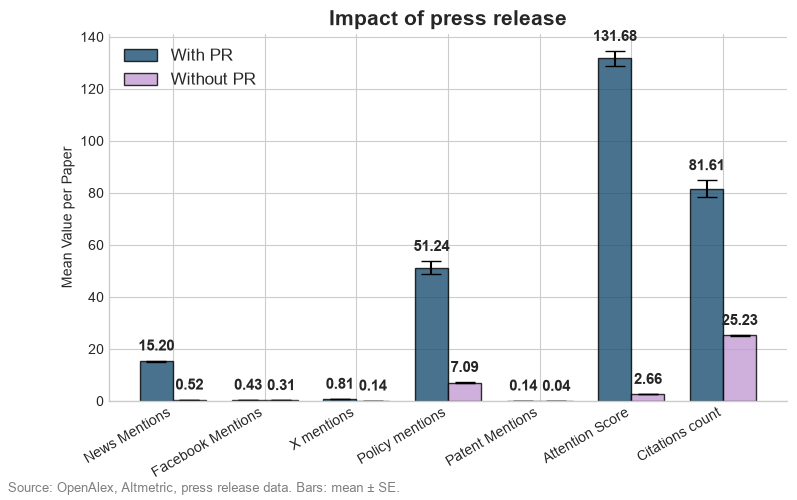

In [18]:
# Get the relevant columns
metrics = ["news_mentions", "patent_mentions", "facebook_mentions", "x_post_mentions","policy_mentions", "attention_score", 'cited_by_count']
group_labels = ["With PR", "Without PR"]

# Prepare data: mean and standard error for each metric for PR/non-PR
means = []
std_errs = []
for has_pr in [True, False]:
    group = paper_df[paper_df["has_pr"] == has_pr]
    means.append([group[m].mean() for m in metrics])
    std_errs.append([group[m].sem() for m in metrics])

means = np.array(means)          # shape (2, N metrics)
std_errs = np.array(std_errs)    # shape (2, N metrics)

# Set up McKinsey-style (simple version)
plt.style.use("seaborn-v0_8-whitegrid")
accent_color = "#1B4F72"       # blue-darkish
gray_light = "#E5E7E9"
colors = [accent_color, "#C39BD3"]  # blue and purple

x = np.arange(len(metrics))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars
for i, (label, color) in enumerate(zip(group_labels, colors)):
    ax.bar(
        x + i*bar_width,
        means[i],
        yerr=std_errs[i],
        width=bar_width,
        label=label,
        color=color,
        edgecolor="black",
        alpha=0.8,
        capsize=7,
    )
    # Direct label on top of each bar
    for j, (mean, err) in enumerate(zip(means[i], std_errs[i])):
        ax.text(
            x[j] + i*bar_width,
            mean + err + 0.02 * (max(means.flatten())),
            f"{mean:.2f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

# X labels
bar_labels = ["News Mentions", "Facebook Mentions", "X mentions", "Policy mentions", "Patent Mentions", "Attention Score", "Citations count"]
ax.set_xticks(x + bar_width/2)
ax.set_xticklabels(bar_labels, rotation=30, ha='right')  # Tilt by 30 degrees

# Add a small vertical line at the center of each group where the x label ends
for idx in range(len(metrics)):
    xpos = x[idx] + bar_width  # in the middle between the two bars (left+1 width)
    ymin, ymax = ax.get_ylim()
    # Set the top of the line just below the axis for visibility
    line_bottom = 0
    line_top = 0.1 * (ymax - ymin)
    # ax.vlines(xpos, ymin=line_bottom, ymax=line_top, colors="gray", linestyles="dashed", lw=1.1, alpha=0.75)

# Insight-style title
ax.set_title(
    "Impact of press release",
    fontsize=15,
    fontweight="bold",
)
ax.set_ylabel("Mean Value per Paper")
ax.set_ylim(bottom=0)
ax.legend(title="", fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Source annotation (bottom left)
ax.annotate(
    "Source: OpenAlex, Altmetric, press release data. Bars: mean ± SE.",
    (0,0),
    xycoords="figure fraction",
    xytext=(0.01, 0.01),
    textcoords="figure fraction",
    ha="left",
    va="bottom",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

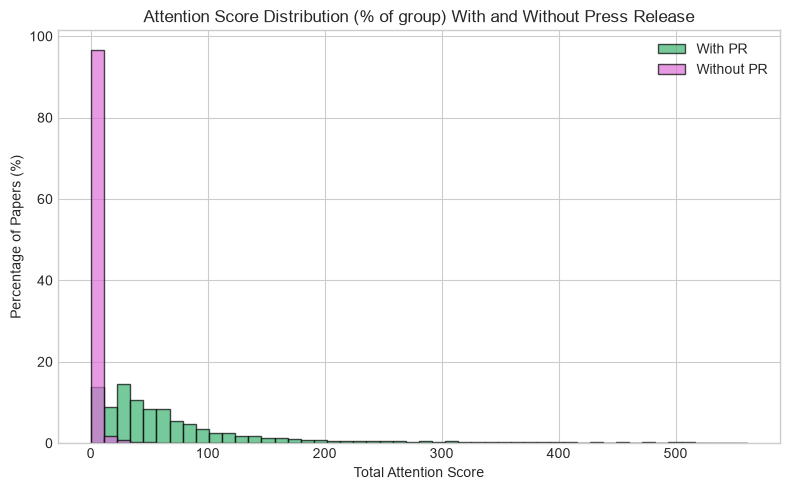

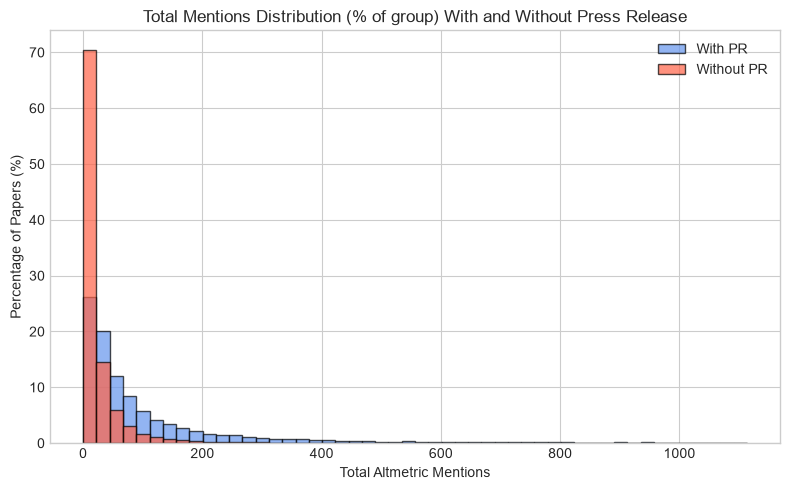

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Subset papers by press release status
attention_with_pr = paper_df[paper_df["has_pr"]]["attention_score"]
attention_without_pr = paper_df[~paper_df["has_pr"]]["attention_score"]

# Compute histogram data
# Limit the x-axis to the 99th percentile of attention scores
xmax = np.percentile(paper_df['attention_score'], 99.9)
bins = 50
counts_with_pr, bin_edges = np.histogram(attention_with_pr[attention_with_pr < xmax], bins=bins)
counts_without_pr, _ = np.histogram(attention_without_pr[attention_without_pr < xmax], bins=bin_edges)

# Convert counts to percentages
total_with_pr = np.sum(counts_with_pr)
total_without_pr = np.sum(counts_without_pr)
percent_with_pr = (counts_with_pr / total_with_pr) * 100
percent_without_pr = (counts_without_pr / total_without_pr) * 100

width = np.diff(bin_edges)

plt.figure(figsize=(8, 5))
plt.bar(
    bin_edges[:-1],
    percent_with_pr,
    width=width,
    color="mediumseagreen",
    alpha=0.7,
    align="edge",
    edgecolor="black",
    label="With PR",
)
plt.bar(
    bin_edges[:-1],
    percent_without_pr,
    width=width,
    color="orchid",
    alpha=0.7,
    align="edge",
    edgecolor="black",
    label="Without PR"
)

plt.xlabel("Total Attention Score")
plt.ylabel("Percentage of Papers (%)")
plt.title("Attention Score Distribution (% of group) With and Without Press Release")
plt.legend()
plt.tight_layout()
plt.show()

# Subset total_mentions by press release status
total_mentions_with_pr = paper_df[paper_df["has_pr"]]["total_mentions"]
total_mentions_without_pr = paper_df[~paper_df["has_pr"]]["total_mentions"]

# Limit the x-axis to the 99th percentile of total mentions
xmax_mentions = np.percentile(paper_df["total_mentions"], 99.9)
bins_mentions = 50
counts_with_pr_mentions, bin_edges_mentions = np.histogram(
    total_mentions_with_pr[total_mentions_with_pr < xmax_mentions],
    bins=bins_mentions
)
counts_without_pr_mentions, _ = np.histogram(
    total_mentions_without_pr[total_mentions_without_pr < xmax_mentions],
    bins=bin_edges_mentions
)

# Convert counts to percentages
total_with_pr_mentions = np.sum(counts_with_pr_mentions)
total_without_pr_mentions = np.sum(counts_without_pr_mentions)
percent_with_pr_mentions = (counts_with_pr_mentions / total_with_pr_mentions) * 100
percent_without_pr_mentions = (counts_without_pr_mentions / total_without_pr_mentions) * 100

width_mentions = np.diff(bin_edges_mentions)

plt.figure(figsize=(8, 5))
plt.bar(
    bin_edges_mentions[:-1],
    percent_with_pr_mentions,
    width=width_mentions,
    color="cornflowerblue",
    alpha=0.7,
    align="edge",
    edgecolor="black",
    label="With PR",
)
plt.bar(
    bin_edges_mentions[:-1],
    percent_without_pr_mentions,
    width=width_mentions,
    color="tomato",
    alpha=0.7,
    align="edge",
    edgecolor="black",
    label="Without PR"
)

plt.xlabel("Total Altmetric Mentions")
plt.ylabel("Percentage of Papers (%)")
plt.title("Total Mentions Distribution (% of group) With and Without Press Release")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
paper_df["log_total_mentions"] = np.log1p(paper_df["total_mentions"])
paper_df["log_attention_score"] = np.log1p(paper_df["attention_score"])

# Drop rows missing controls
paper_df = paper_df.dropna(subset=["pub_year", "entity_name"]).copy()
print(paper_df["has_pr"].value_counts())
print(paper_df[["total_mentions", "attention_score"]].describe())

has_pr
False    1041063
True       14111
Name: count, dtype: int64
       total_mentions  attention_score
count    1.055174e+06     1.055174e+06
mean     2.996186e+01     4.383084e+00
std      1.475523e+02     5.853942e+01
min      0.000000e+00     0.000000e+00
25%      2.000000e+00     0.000000e+00
50%      1.000000e+01     0.000000e+00
75%      2.800000e+01     5.000000e-01
max      5.470900e+04     1.254500e+04


In [21]:
# total_mentions ~ has_pr + pub_year + entity fixed effects
# family=NegativeBinomial or Poisson

import pyfixest as pf
vcov_entity = {"CRV1": "entity_name"}

# A) Log-linear model (easy interpretation on skewed counts)
m_log_total = pf.feols(
    "log_total_mentions ~ has_pr | pub_year + entity_name",
    data=paper_df,
    vcov=vcov_entity,
)

m_log_total.summary()


d:\gaTech\EuerkAlertWork\.venv\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: log_total_mentions, Fixed effects: pub_year + entity_name
sample: None = all
Inference:  CRV1
Observations:  1055173

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| has_pr        |      1.958 |        0.113 |    17.365 |      0.000 |  1.731 |   2.186 |
---
RMSE: 1.38 R2: 0.136 R2 Within: 0.025 


In [22]:
# attention_score ~ has_pr + pub_year + entity fixed effects
# family=NegativeBinomial or Poisson

import pyfixest as pf
vcov_entity = {"CRV1": "entity_name"}

# A) Log-linear model (easy interpretation on skewed counts)
m_log_total = pf.feols(
    "log_attention_score ~ has_pr | pub_year + entity_name",
    data=paper_df,
    vcov=vcov_entity,
)

m_log_total.summary()


d:\gaTech\EuerkAlertWork\.venv\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: log_attention_score, Fixed effects: pub_year + entity_name
sample: None = all
Inference:  CRV1
Observations:  1055173

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| has_pr        |      3.460 |        0.093 |    37.304 |      0.000 |  3.273 |   3.648 |
---
RMSE: 0.813 R2: 0.2 R2 Within: 0.19 


In [23]:
m_pois_total = pf.fepois(
    "total_mentions ~ has_pr | pub_year + entity_name",
    data=paper_df,
    vcov=vcov_entity,
)
m_pois_total.summary()


d:\gaTech\EuerkAlertWork\.venv\Lib\site-packages\pyfixest\estimation\formula\model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


###

Estimation:  Poisson
Dep. var.: total_mentions, Fixed effects: pub_year + entity_name
sample: None = all
Inference:  CRV1
Observations:  1055173

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| has_pr        |      1.923 |        0.069 |    27.739 |      0.000 |  1.787 |   2.059 |
---
Deviance: 69728959.807 


In [21]:

# C) Channel-specific Poisson models (news is most PR-relevant)
m_pois_news = pf.fepois(
    "news_mentions ~ has_pr | pub_year + entity_name",
    data=paper_df,
    vcov=vcov_entity,
)
m_pois_news.summary()


d:\gaTech\EuerkAlertWork\.venv\Lib\site-packages\pyfixest\estimation\models\fepois_.py:576: UserWarning: 18 observations removed because of separation.
  warnings.warn(


###

Estimation:  Poisson
Dep. var.: news_mentions, Fixed effects: pub_year + entity_name
sample: None = all
Inference:  CRV1
Observations:  193880

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| has_pr        |      3.256 |        0.047 |    69.319 |      0.000 |  3.164 |   3.348 |
---
Deviance: 819237.272 


In [22]:
def pct_effect_from_log_coef(model, var="has_pr"):
    b = model.coef().loc[var]
    return np.exp(b), (np.exp(b - 1.96 * model.se().loc[var]), np.exp(b + 1.96 * model.se().loc[var]))
    
mult, ci = pct_effect_from_log_coef(m_pois_total)
print(f"Poisson total mentions: PR papers have {mult:.2f}x expected mentions (95% CI: {ci[0]:.2f}, {ci[1]:.2f})")
mult_news, ci_news = pct_effect_from_log_coef(m_pois_news)
print(f"Poisson news mentions: PR papers have {mult_news:.2f}x expected news mentions (95% CI: {ci_news[0]:.2f}, {ci_news[1]:.2f})")

Poisson total mentions: PR papers have 17.14x expected mentions (95% CI: 14.10, 20.84)
Poisson news mentions: PR papers have 25.95x expected news mentions (95% CI: 23.67, 28.46)


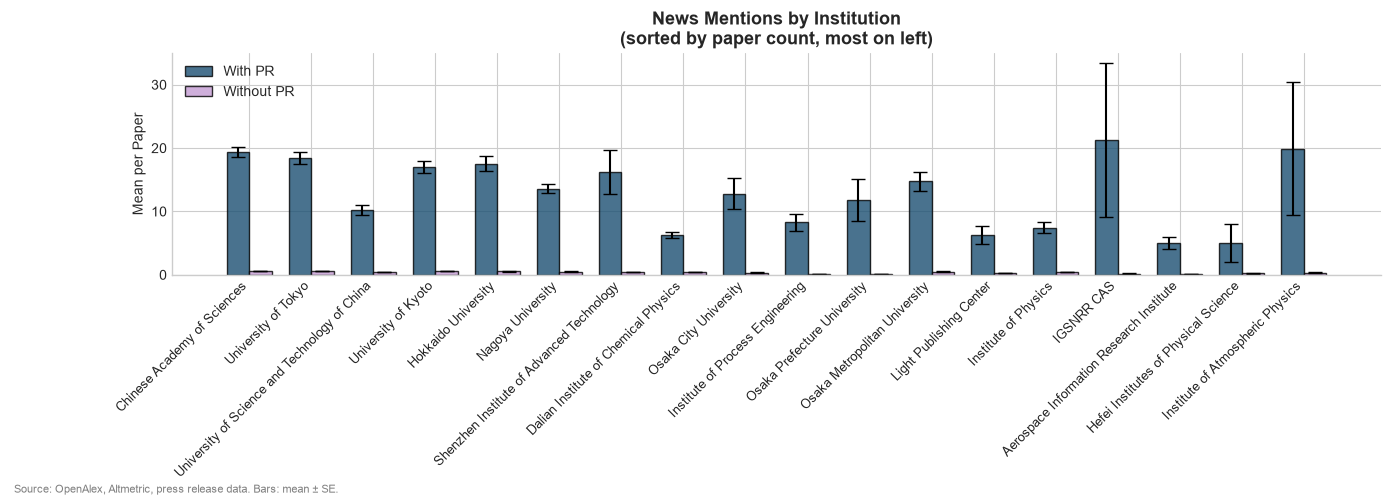

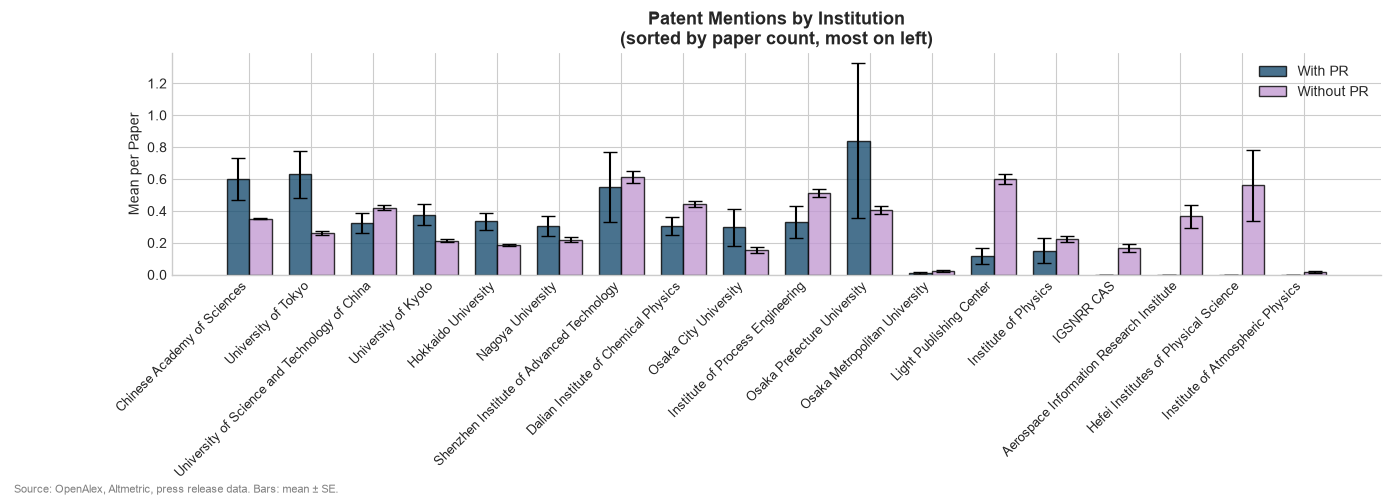

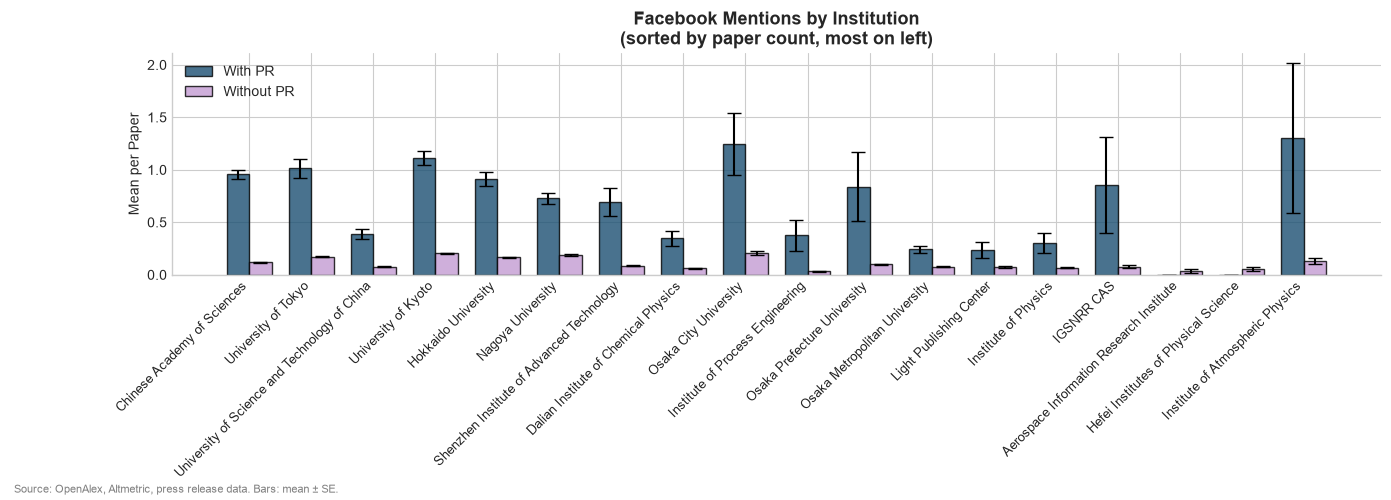

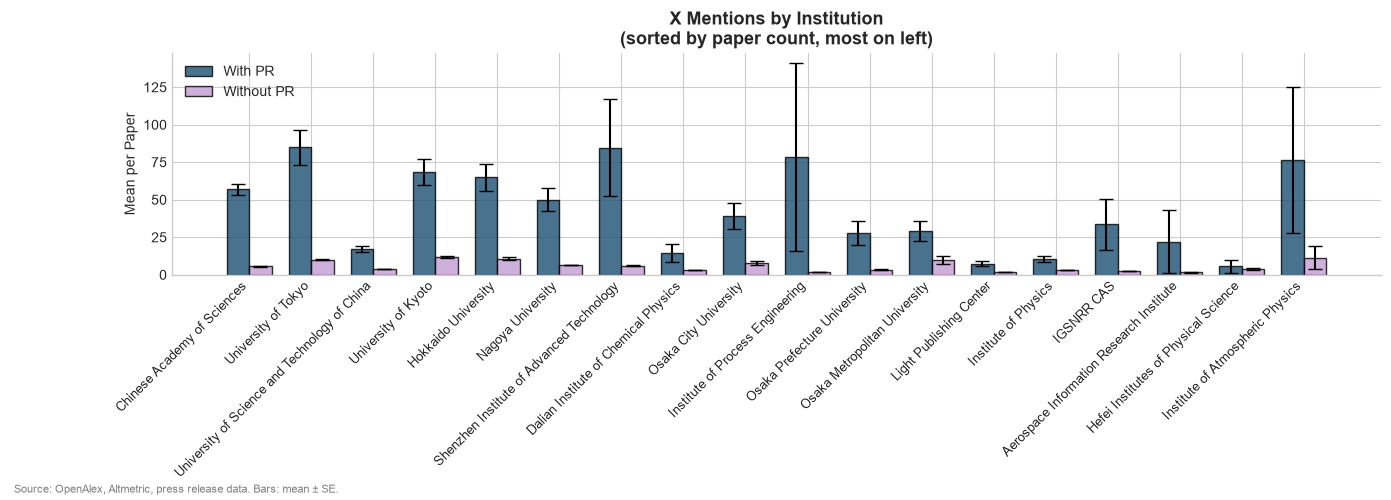

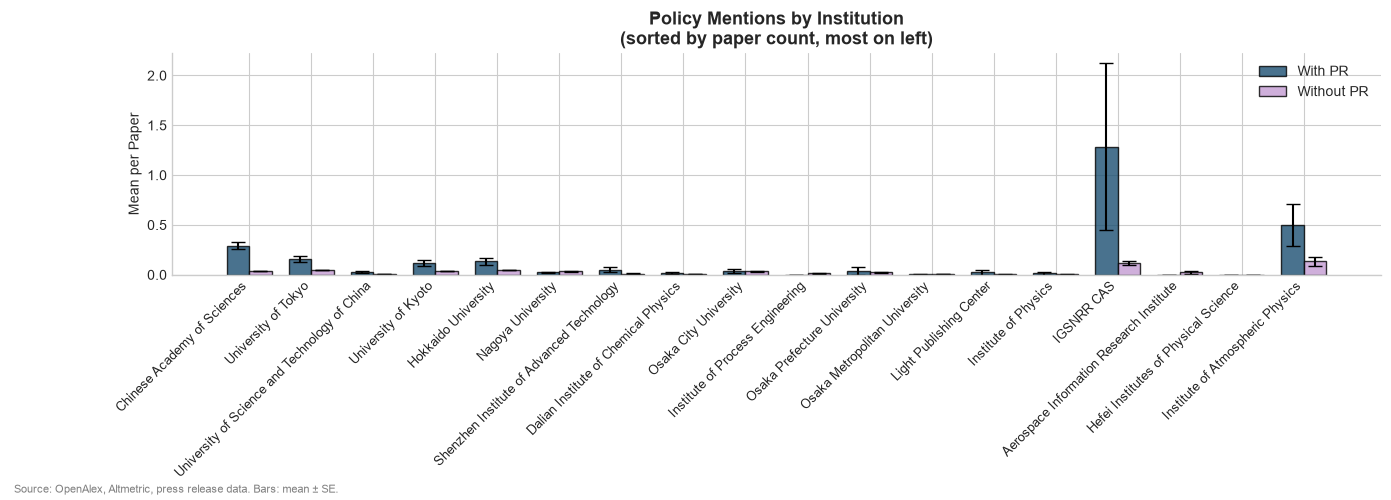

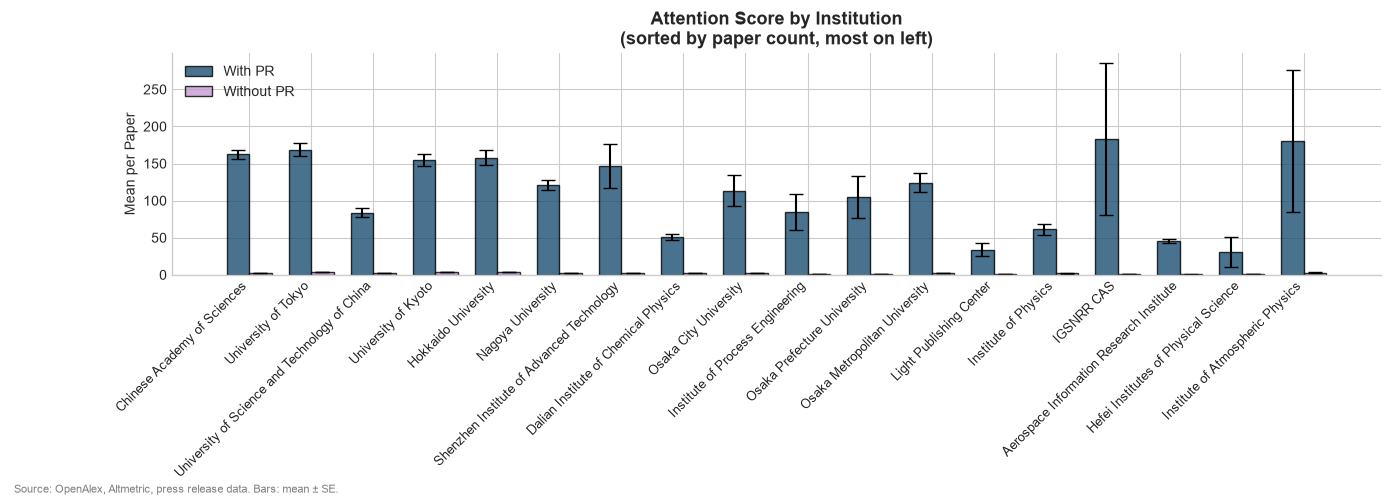

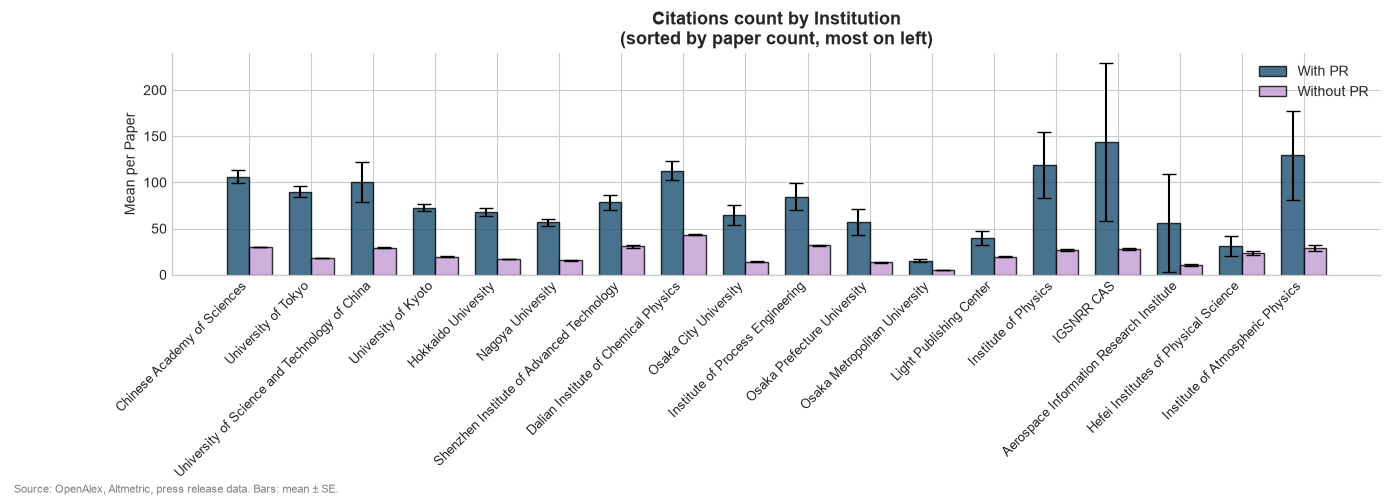

In [24]:

# ── Six separate plots — one per metric, grouped by institution ──────────────
# X-axis = institutions sorted by paper count (most on the left).
# Two bars per institution: With PR (blue) vs Without PR (purple).

metrics = [
    "news_mentions",
    "patent_mentions",
    "facebook_mentions",
    "x_post_mentions",
    "policy_mentions",
    "attention_score",
    'cited_by_count'
]
metric_labels = [
    "News Mentions",
    "Patent Mentions",
    "Facebook Mentions",
    "X Mentions",
    "Policy Mentions",
    "Attention Score",
    "Citations count"
]

# ── Filter to institutions only ──────────────────────────────────────────────
inst_df = paper_df[paper_df["category"] == "institution"].copy()

# ── Sort institutions by total paper count (descending) ─────────────────────
inst_order = (
    inst_df.groupby("entity_name")
    .size()
    .sort_values(ascending=False)
    .index.tolist()
)
short_names = [n.split(",")[0].strip() for n in inst_order]

# ── Visual style ─────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
colors = ["#1B4F72", "#C39BD3"]   # blue = With PR, purple = Without PR
bar_width = 0.36
x = np.arange(len(inst_order))

for metric, metric_label in zip(metrics, metric_labels):

    means_pr, means_no_pr = [], []
    errs_pr,  errs_no_pr  = [], []

    for inst in inst_order:
        sub        = inst_df[inst_df["entity_name"] == inst]
        with_pr    = sub[sub["has_pr"] == 1][metric]
        without_pr = sub[sub["has_pr"] == 0][metric]
        means_pr.append(with_pr.mean())
        errs_pr.append(with_pr.sem())
        means_no_pr.append(without_pr.mean())
        errs_no_pr.append(without_pr.sem())

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.bar(x,             means_pr,    yerr=errs_pr,
           width=bar_width, label="With PR",    color=colors[0],
           edgecolor="black", alpha=0.8, capsize=5)
    ax.bar(x + bar_width, means_no_pr, yerr=errs_no_pr,
           width=bar_width, label="Without PR", color=colors[1],
           edgecolor="black", alpha=0.8, capsize=5)

    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=9)
    ax.set_title(
        f"{metric_label} by Institution\n(sorted by paper count, most on left)",
        fontsize=13, fontweight="bold",
    )
    ax.set_ylabel("Mean per Paper")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.annotate(
        "Source: OpenAlex, Altmetric, press release data. Bars: mean ± SE.",
        (0, 0), xycoords="figure fraction", xytext=(0.01, 0.01),
        textcoords="figure fraction", ha="left", va="bottom",
        fontsize=8, color="gray",
    )

    plt.tight_layout()
    plt.show()

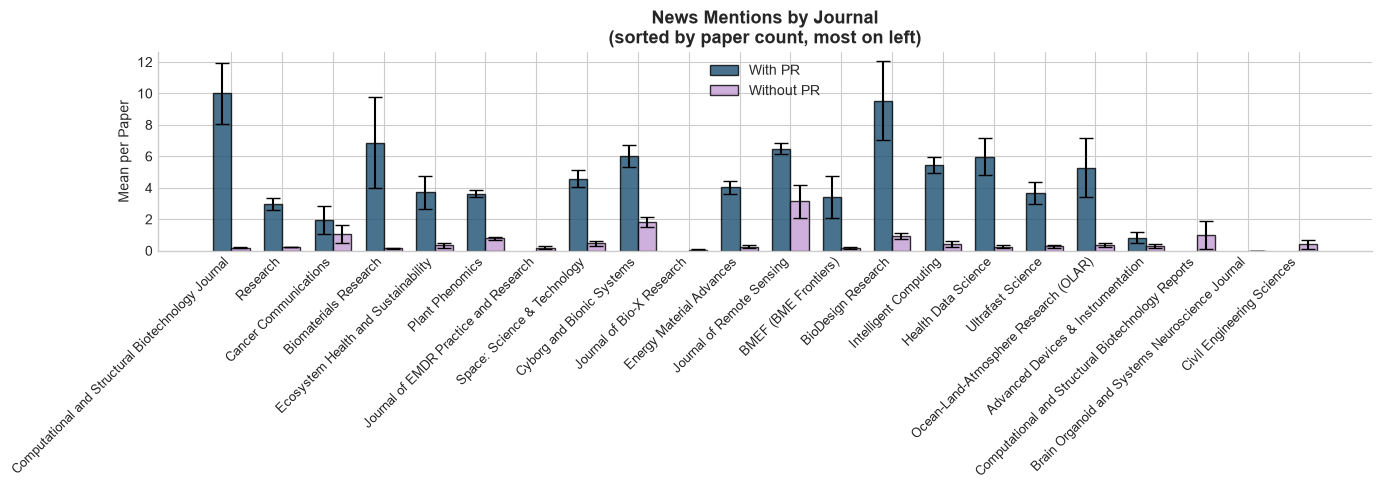

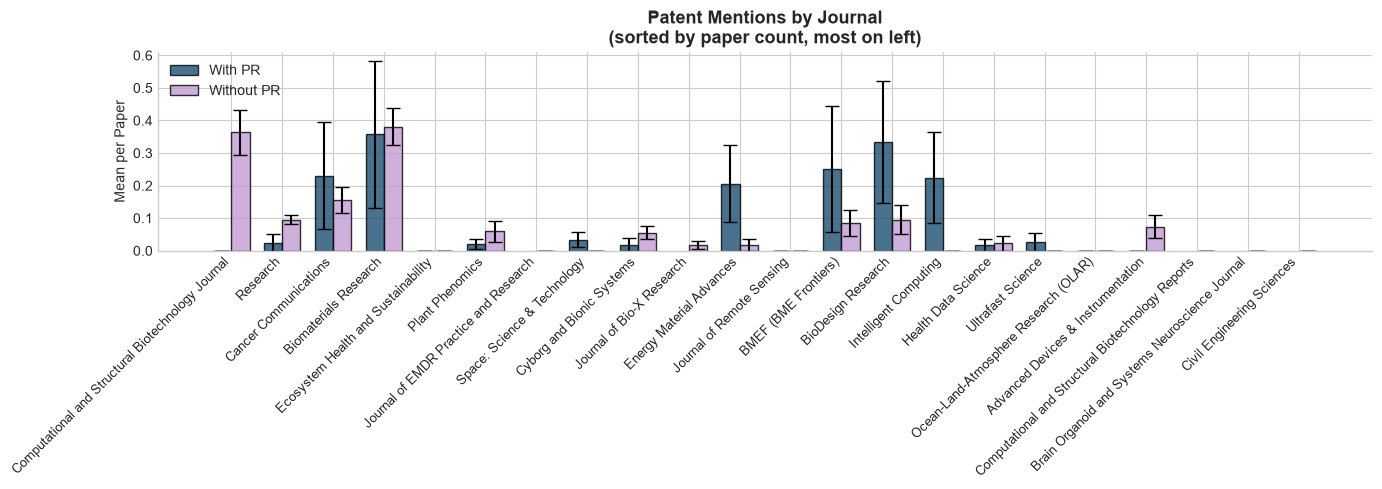

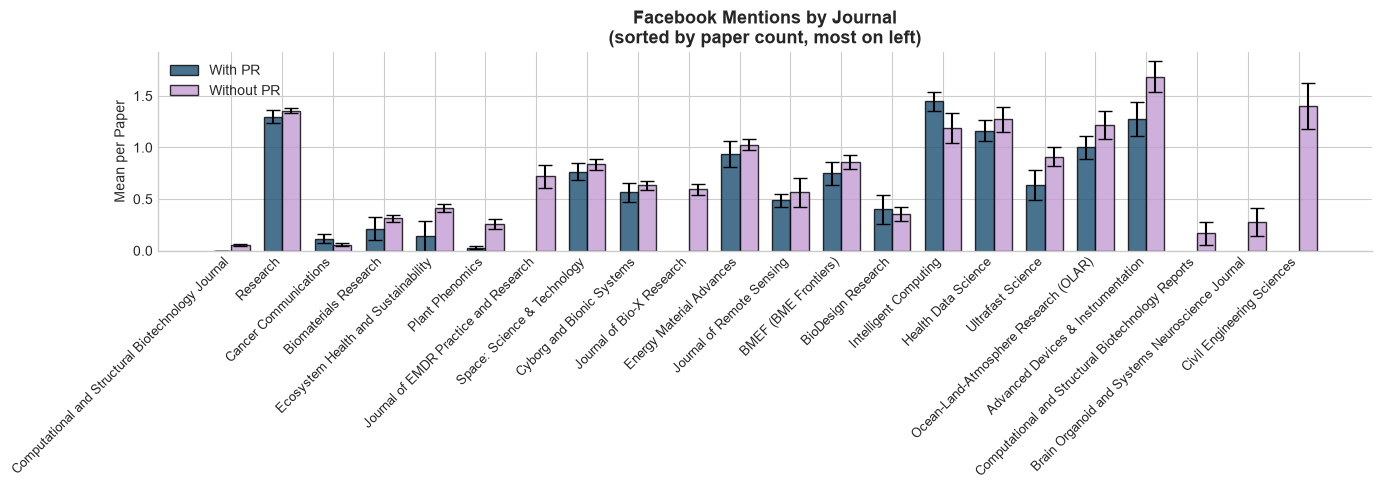

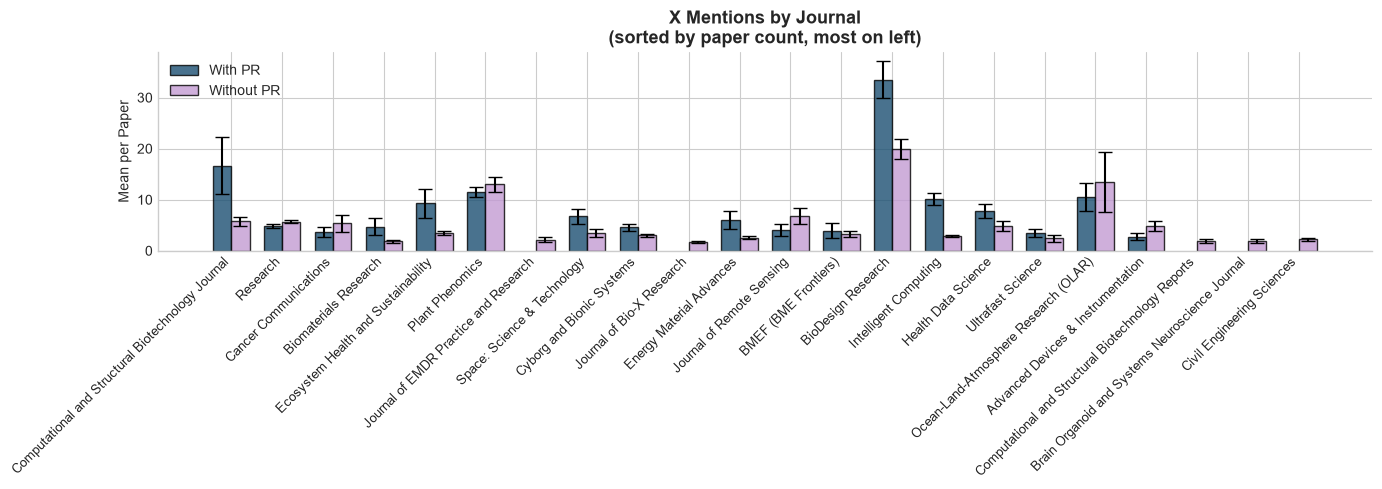

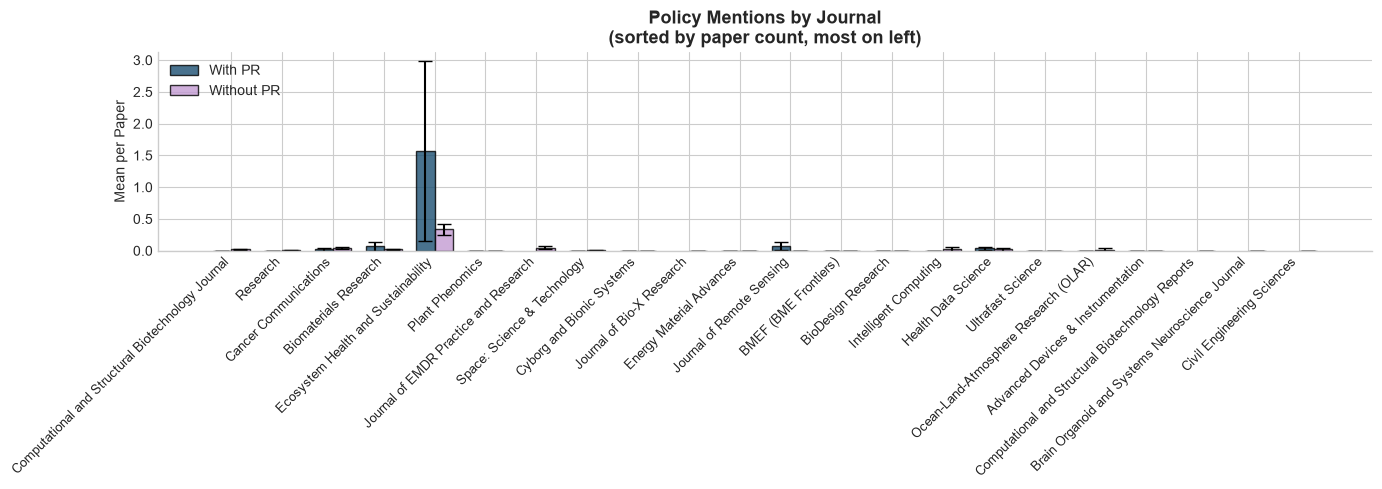

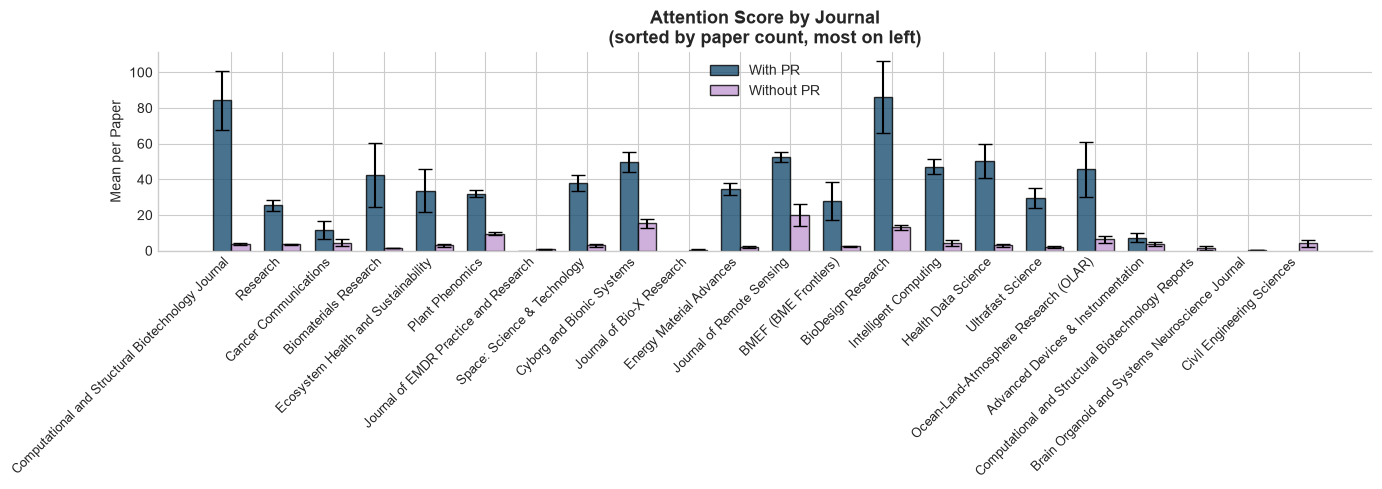

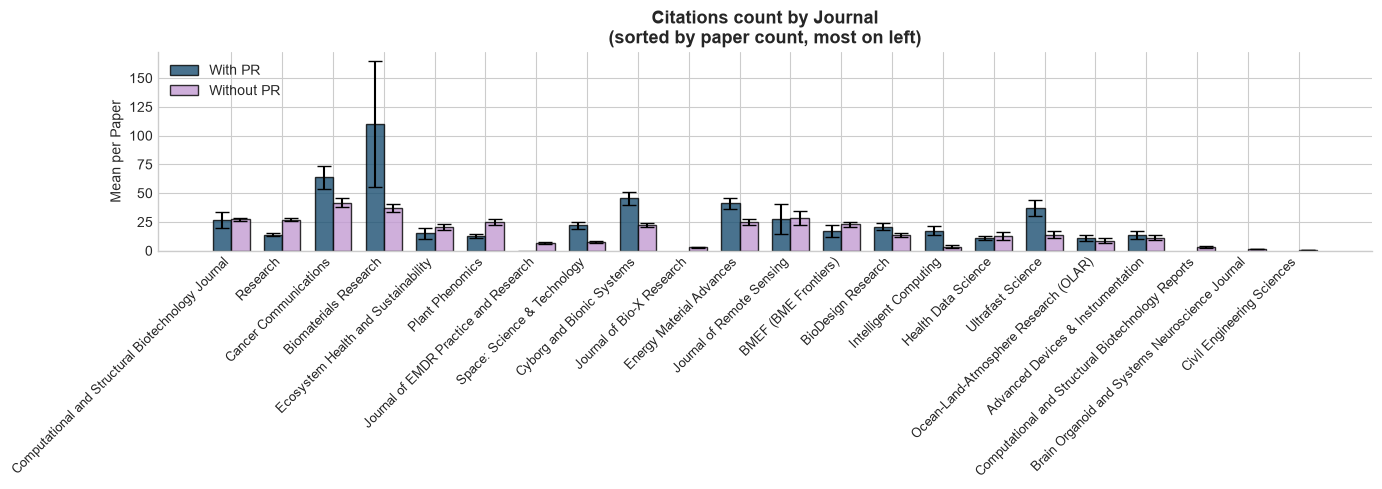

: 

In [ ]:

# ── Six separate plots — one per metric, grouped by journal ─────────────────
# X-axis = journals sorted by paper count (most on the left).
# Two bars per journal: With PR (blue) vs Without PR (purple).

# ── Filter to journals only ──────────────────────────────────────────────────
jour_df = paper_df[paper_df["category"] == "journal"].copy()

# ── Sort journals by total paper count (descending) ──────────────────────────
jour_order = (
    jour_df.groupby("entity_name")
    .size()
    .sort_values(ascending=False)
    .index.tolist()
)
short_jour_names = [n.split(",")[0].strip() for n in jour_order]

# ── Visual style ─────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
colors = ["#1B4F72", "#C39BD3"]   # blue = With PR, purple = Without PR
bar_width = 0.36
x = np.arange(len(jour_order))

for metric, metric_label in zip(metrics, metric_labels):

    means_pr, means_no_pr = [], []
    errs_pr,  errs_no_pr  = [], []

    for jour in jour_order:
        sub        = jour_df[jour_df["entity_name"] == jour]
        with_pr    = sub[sub["has_pr"] == 1][metric]
        without_pr = sub[sub["has_pr"] == 0][metric]
        means_pr.append(with_pr.mean())
        errs_pr.append(with_pr.sem())
        means_no_pr.append(without_pr.mean())
        errs_no_pr.append(without_pr.sem())

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.bar(x,             means_pr,    yerr=errs_pr,
           width=bar_width, label="With PR",    color=colors[0],
           edgecolor="black", alpha=0.8, capsize=5)
    ax.bar(x + bar_width, means_no_pr, yerr=errs_no_pr,
           width=bar_width, label="Without PR", color=colors[1],
           edgecolor="black", alpha=0.8, capsize=5)

    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels(short_jour_names, rotation=45, ha="right", fontsize=9)
    ax.set_title(
        f"{metric_label} by Journal\n(sorted by paper count, most on left)",
        fontsize=13, fontweight="bold",
    )
    ax.set_ylabel("Mean per Paper")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


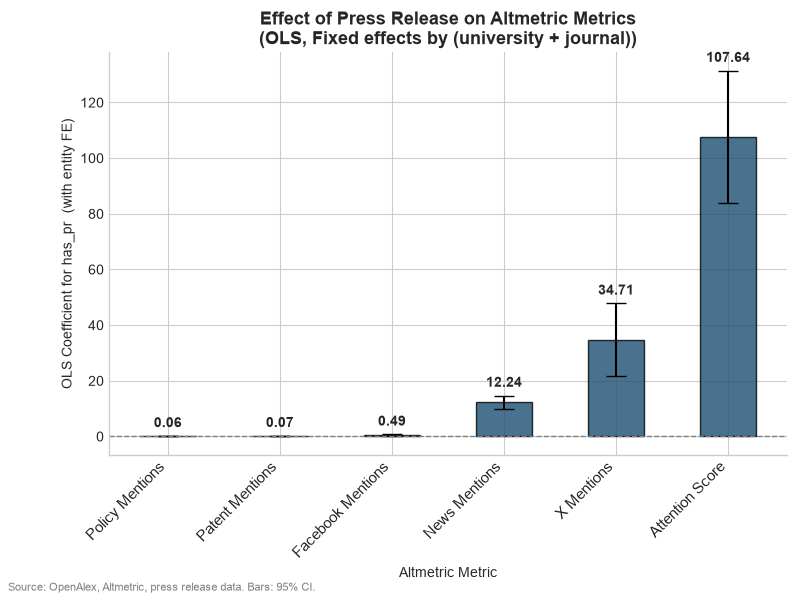

: 

In [ ]:

# ── Coefficient plot (forest plot) — has_pr effect across metrics ────────────
# Each row = one metric. Dot = OLS estimate, bar = 95% CI.
# Metrics sorted by coefficient size (largest effect at the top).
import pyfixest as pf
vcov_entity = {"CRV1": "entity_name"}

models = {}

for m in metrics:
    models[m] = pf.feols(
        f"{m} ~ has_pr | entity_name",
        data=paper_df,
        vcov=vcov_entity,
    )

metric_labels_map = {
    "news_mentions":     "News Mentions",
    "patent_mentions":   "Patent Mentions",
    "facebook_mentions": "Facebook Mentions",
    "x_post_mentions":   "X Mentions",
    "policy_mentions":   "Policy Mentions",
    "attention_score":   "Attention Score",
}

rows = []
for m, model in models.items():
    coef = model.coef().loc["has_pr"]
    se   = model.se().loc["has_pr"]
    rows.append({
        "metric": metric_labels_map.get(m, m),
        "coef":   coef,
        "ci_lo":  coef - 1.96 * se,
        "ci_hi":  coef + 1.96 * se,
    })

coef_df = (
    pd.DataFrame(rows)
    .sort_values("coef", ascending=True)   # largest on top when x is reversed in vertical
    .reset_index(drop=True)
)

# ── Plot (ROTATED: now vertical forest plot, horizontal = metrics) ─────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))  # Make it taller for more metrics

x = np.arange(len(coef_df))

# Plot vertical bars with error bars representing 95% CI
ax.bar(
    x,
    coef_df["coef"],
    yerr=np.array([
        coef_df["coef"] - coef_df["ci_lo"],
        coef_df["ci_hi"] - coef_df["coef"],
    ]),
    width=0.5,
    color="#1B4F72",
    edgecolor="black",
    alpha=0.8,
    capsize=7,
    error_kw={"elinewidth": 1.5, "ecolor": "black"},
)

# Coefficient labels at the top of each bar
for i, row in coef_df.iterrows():
    ax.text(
        i,
        row["ci_hi"] + 0.02 * abs(coef_df["coef"].max()),   # put a bit above the CI bar
        f"{row['coef']:.2f}",
        va="bottom", ha="center", fontsize=10, fontweight="bold",
    )

ax.set_xticks(x)
ax.set_xticklabels(coef_df["metric"], rotation=45, ha="right", fontsize=11)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_ylabel("OLS Coefficient for has_pr  (with entity FE)", fontsize=10)
ax.set_xlabel("Altmetric Metric", fontsize=10)
ax.set_title(
    "Effect of Press Release on Altmetric Metrics\n(OLS, Fixed effects by (university + journal))",
    fontsize=13, fontweight="bold",
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.annotate(
    "Source: OpenAlex, Altmetric, press release data. Bars: 95% CI.",
    (0, 0), xycoords="figure fraction", xytext=(0.01, 0.01),
    textcoords="figure fraction", ha="left", va="bottom",
    fontsize=8, color="gray",
)

plt.tight_layout()
plt.show()


In [ ]:

# Search names that never matched any press release
# Flips the join: start from name_variations, LEFT JOIN to pr_base,
# keep only rows where no PR matched any of the five text fields.

unmatched_query = '''
WITH name_variations AS (
  SELECT * FROM (VALUES
  ('journal', 'Advanced Devices & Instrumentation', 'Adv Devices Instrum'),
  ('journal', 'Advanced Devices & Instrumentation', 'Advanced Devices and Instrumentation'),
  ('journal', 'Advanced Devices & Instrumentation', 'Advanced Devices & Instrumentation'),
  ('journal', 'Energy Material Advances', 'Energy Material Advances'),
  ('journal', 'Energy Material Advances', 'Energy Materials Advances'),
  ('journal', 'Energy Material Advances', 'Energy Material Adv'),
  ('journal', 'Space: Science & Technology', 'Space: Science & Technology'),
  ('journal', 'Space: Science & Technology', 'Space: Science and Technology'),
  ('journal', 'Space: Science & Technology', 'Space Sci Technol'),
  ('journal', 'Space: Science & Technology', 'Space Science & Technology'),
  ('journal', 'Space: Science & Technology', 'Space Science and Technology'),
  ('journal', 'Cyborg and Bionic Systems', 'Cyborg Bionic Systems'),
  ('journal', 'Cyborg and Bionic Systems', 'Cyborg & Bionic Systems'),
  ('journal', 'Cyborg and Bionic Systems', 'Cyborg and Bionic Systems'),
  ('journal', 'BioDesign Research', 'BioDesign Research'),
  ('journal', 'BioDesign Research', 'BioDesign Res'),
  ('journal', 'BioDesign Research', 'Bio-Design Research'),
  ('journal', 'BioDesign Research', 'Bio Design Research'),
  ('journal', 'Biomaterials Research', 'Biomaterials Res'),
  ('journal', 'Biomaterials Research', 'Biomaterials Research'),
  ('journal', 'BMEF (BME Frontiers)', 'BMEF (BME Frontiers)'),
  ('journal', 'BMEF (BME Frontiers)', 'BME Frontiers'),
  ('journal', 'BMEF (BME Frontiers)', 'BMEF'),
  ('journal', 'Ecosystem Health and Sustainability', 'Ecosystem Health and Sustainability'),
  ('journal', 'Ecosystem Health and Sustainability', 'Ecosystem Health Sustain'),
  ('journal', 'Ecosystem Health and Sustainability', 'Ecosystem Health & Sustainability'),
  ('journal', 'Health Data Science', 'Health Data Sci'),
  ('journal', 'Health Data Science', 'Health Data Science'),
  ('journal', 'Intelligent Computing', 'Intell Computing'),
  ('journal', 'Intelligent Computing', 'Intelligent Comput'),
  ('journal', 'Intelligent Computing', 'Intelligent Computing'),
  ('journal', 'Journal of Bio-X Research', 'Journal of Bio-X Research'),
  ('journal', 'Journal of Bio-X Research', 'Bio X Research'),
  ('journal', 'Journal of Bio-X Research', 'J Bio-X Res'),
  ('journal', 'Journal of Bio-X Research', 'Bio-X Research'),
  ('journal', 'Journal of Bio-X Research', 'Journal of Bio X Research'),
  ('journal', 'Journal of Remote Sensing', 'Journal of Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'J Remote Sens'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean-Land-Atmosphere Research'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean Land Atmosphere Research'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean-Land-Atmosphere Research (OLAR)'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean-Land-Atmosphere Res'),
  ('journal', 'Plant Phenomics', 'Plant Phenomics journal'),
  ('journal', 'Plant Phenomics', 'Plant Phenomics'),
  ('journal', 'Research', 'Science Partner Journal Research'),
  ('journal', 'Ultrafast Science', 'Ultrafast Sci'),
  ('journal', 'Ultrafast Science', 'Ultrafast Science'),
  ('journal', 'Journal of EMDR Practice and Research', 'J EMDR Pract Res'),
  ('journal', 'Journal of EMDR Practice and Research', 'Journal of EMDR Practice & Research'),
  ('journal', 'Journal of EMDR Practice and Research', 'Journal of EMDR Practice and Research'),
  ('journal', 'Journal of EMDR Practice and Research', 'EMDR Practice and Research'),
  ('institution', 'Science Partner Journals', 'Science Partner Journals (SPJ)'),
  ('institution', 'Science Partner Journals', 'AAAS Science Partner Journals'),
  ('institution', 'Science Partner Journals', 'Science Partner Journals'),
  ('institution', 'Science Partner Journals', 'Science Partner Journal'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'Beijing Institute of Technology Press Co., Ltd'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'Beijing Inst of Technology Press'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'Beijing Institute of Technology Press'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'BIT Press'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'Beijing Institute of Technology Press Co Ltd'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'Chinese Academy of Sciences (CAS)'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'The Chinese Academy of Sciences'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'CAS Headquarters'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'Chinese Academy of Science'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'Chinese Academy of Sciences Headquarters'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'Chinese Academy of Sciences'),
  ('institution', 'University of Science and Technology of China', 'Univ of Sci and Tech of China'),
  ('institution', 'University of Science and Technology of China', 'University of Science and Technology of China'),
  ('institution', 'University of Science and Technology of China', 'Univ. of Science and Technology of China'),
  ('institution', 'Institute of Physics, Chinese Academy of Sciences', 'Institute of Physics, Chinese Academy of Sciences'),
  ('institution', 'Institute of Physics, Chinese Academy of Sciences', 'Institute of Physics CAS'),
  ('institution', 'Institute of Physics, Chinese Academy of Sciences', 'Institute of Physics, CAS'),
  ('institution', 'Institute of Physics, Chinese Academy of Sciences', 'IOP CAS'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'IPE CAS'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'Institute of Process Engineering'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'Institute of Process Engineering, Chinese Academy of Sciences'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'IPE-CAS'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'Institute of Process Engineering CAS'),
  ('institution', 'IGSNRR CAS', 'IGSNRR CAS'),
  ('institution', 'IGSNRR CAS', 'Institute of Geographic Sciences and Natural Resources Research CAS'),
  ('institution', 'IGSNRR CAS', 'Institute of Geographic Sciences and Natural Resources Research'),
  ('institution', 'IGSNRR CAS', 'Institute of Geographic Sciences and Natural Resources Research, CAS'),
  ('institution', 'IGSNRR CAS', 'IGSNRR'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'Institute of Atmospheric Physics CAS'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'IAP CAS'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'Institute of Atmospheric Physics'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'Institute of Atmospheric Physics, Chinese Academy of Sciences'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'IAP-CAS'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'Aerospace Information Research Institute, Chinese Academy of Sciences'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'Aerospace Information Research Institute'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'Aerospace Information Research Institute CAS'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'AIRI CAS'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'AIR CAS'),
  ('institution', 'Dalian Institute of Chemical Physics, Chinese Academy Sciences', 'Dalian Institute of Chemical Physics, Chinese Academy Sciences'),
  ('institution', 'Dalian Institute of Chemical Physics, Chinese Academy Sciences', 'Dalian Institute of Chemical Physics'),
  ('institution', 'Dalian Institute of Chemical Physics, Chinese Academy Sciences', 'Dalian Institute of Chemical Physics, Chinese Academy of Sciences'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Changchun Institute of Optics Fine Mechanics and Physics CAS'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Changchun Institute of Optics, Fine Mechanics and Physics'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'CIOMP'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Light Publishing Center CIOMP'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Changchun Institute of Optics, Fine Mechanics And Physics'),
  ('institution', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences', 'Hefei Institutes of Physical Science'),
  ('institution', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences', 'HFIPS CAS'),
  ('institution', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences', 'Hefei Institutes of Physical Science CAS'),
  ('institution', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences'),
  ('institution', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences', 'Shenzhen Institutes of Advanced Technology'),
  ('institution', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences', 'Shenzhen Institute of Advanced Technology'),
  ('institution', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences'),
  ('institution', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences', 'SIAT CAS'),
  ('institution', 'Higher Education Press', 'Higher Education Press'),
  ('institution', 'Higher Education Press', 'Higher Ed Press'),
  ('institution', 'Tsinghua University Press', 'Tsinghua Univ. Press'),
  ('institution', 'Tsinghua University Press', 'Tsinghua University Press'),
  ('institution', 'Tsinghua University Press', 'Tsinghua Univ Press'),
  ('institution', 'Shanghai Jiao Tong University Journal Center', 'SJTU Journal Center'),
  ('institution', 'Shanghai Jiao Tong University Journal Center', 'Shanghai Jiao Tong University Journal Center'),
  ('institution', 'Shanghai Jiao Tong University Journal Center', 'Shanghai Jiao Tong Univ Journal Center'),
  ('institution', 'Shanghai Jiao Tong University Journal Center', 'Shanghai Jiao Tong University Journal Centre'),
  ('institution', 'Nagoya University', 'Univ. Nagoya'),
  ('institution', 'Nagoya University', 'Univ Nagoya'),
  ('institution', 'Nagoya University', 'Nagoya Univ'),
  ('institution', 'Nagoya University', 'Nagoya University'),
  ('institution', 'Hokkaido University', 'Hokkaido University'),
  ('institution', 'Hokkaido University', 'Univ Hokkaido'),
  ('institution', 'Hokkaido University', 'Hokkaido Univ'),
  ('institution', 'Hokkaido University', 'Univ. Hokkaido'),
  ('institution', 'University of Tokyo', 'UTokyo'),
  ('institution', 'University of Tokyo', 'U Tokyo'),
  ('institution', 'University of Tokyo', 'Uni. Tokyo'),
  ('institution', 'University of Tokyo', 'The University of Tokyo'),
  ('institution', 'University of Tokyo', 'Tokyo University'),
  ('institution', 'University of Tokyo', 'University of Tokyo'),
  ('institution', 'University of Kyoto', 'Uni. Kyoto'),
  ('institution', 'University of Kyoto', 'University of Kyoto'),
  ('institution', 'University of Kyoto', 'Kyoto University'),
  ('institution', 'University of Kyoto', 'Kyoto Univ'),
  ('institution', 'University of Kyoto', 'Univ. Kyoto'),
  ('institution', 'Osaka Metropolitan University', 'Osaka Met Univ'),
  ('institution', 'Osaka Metropolitan University', 'Osaka Metropolitan Univ'),
  ('institution', 'Osaka Metropolitan University', 'Osaka Metropolitan University'),
  ('institution', 'Osaka City University', 'Osaka City University'),
  ('institution', 'Osaka City University', 'Osaka City Univ'),
  ('institution', 'Osaka City University', 'Osaka City University (former name of Osaka Metropolitan University)'),
  ('institution', 'Osaka Prefecture University', 'Osaka Prefecture University'),
  ('institution', 'Osaka Prefecture University', 'Osaka Prefecture Univ'),
  ('institution', 'Osaka Prefecture University', 'Osaka Prefecture University (former name of Osaka Metropolitan University)'),
  ('journal', 'Cancer Communications', 'Cancer Research'),
  ('journal', 'Cancer Communications', 'Journal of Cancer'),
  ('journal', 'Cancer Communications', 'Journal Cancer'),
  ('journal', 'Cancer Communications', 'Cancer Reports'),
  ('journal', 'Cancer Communications', 'The Cancer Journal'),
  ('journal', 'Cancer Communications', 'Cancer Communications'),
  ('journal', 'Biomaterials Research', 'Biomaterials'),
  ('journal', 'Biomaterials Research', 'Biomaterials Science'),
  ('journal', 'Biomaterials Research', 'Cell Biomaterials'),
  ('journal', 'Biomaterials Research', 'Advanced Biomaterials'),
  ('journal', 'Biomaterials Research', 'Society for Biomaterials'),
  ('journal', 'Journal of Remote Sensing', 'Journal of Applied Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'International Journal of Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'Frontiers in Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'European Journal of Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'National Remote Sensing Bulletin'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean-Land-Atmosphere Research'),
  ('journal', 'Computational and Structural Biotechnology Journal', 'Computational and Structural Biotechnology Journal'),
  ('journal', 'Space: Science & Technology', 'Space Science & Technology'),
  ('journal', 'Space: Science & Technology', 'Space：Science & Technology')
  ) AS t(entity_category, canonical_name, search_name)
),
match_counts AS (
  SELECT
    nv.entity_category,
    nv.canonical_name,
    nv.search_name,
    count(pr."PR ID") AS pr_hit_count
  FROM name_variations nv
  LEFT JOIN pr_base pr
    ON coalesce(pr."Full Text", '')         ILIKE '%' || nv.search_name || '%'
    OR coalesce(pr."Summary", '')           ILIKE '%' || nv.search_name || '%'
    OR coalesce(pr."Organization", '')      ILIKE '%' || nv.search_name || '%'
    OR coalesce(pr."Journal (Matched)", '') ILIKE '%' || nv.search_name || '%'
    OR coalesce(pr."Journal (Typed)", '')   ILIKE '%' || nv.search_name || '%'
  GROUP BY nv.entity_category, nv.canonical_name, nv.search_name
)
SELECT
  entity_category,
  canonical_name,
  search_name,
  pr_hit_count
FROM match_counts
WHERE pr_hit_count = 0
ORDER BY entity_category, canonical_name, search_name
'''

unmatched_df = con.sql(unmatched_query).df()
print(f"{len(unmatched_df)} search names never matched any press release")
unmatched_df


In [ ]:

# Press releases that were not matched by any search name in name_variations.
# These PRs have no hit across Full Text, Summary, Organization,
# Journal (Matched), or Journal (Typed) for any known entity alias.

unmatched_prs_query = '''
WITH name_variations AS (
  SELECT * FROM (VALUES
  ('journal', 'Advanced Devices & Instrumentation', 'Adv Devices Instrum'),
  ('journal', 'Advanced Devices & Instrumentation', 'Advanced Devices and Instrumentation'),
  ('journal', 'Advanced Devices & Instrumentation', 'Advanced Devices & Instrumentation'),
  ('journal', 'Energy Material Advances', 'Energy Material Advances'),
  ('journal', 'Energy Material Advances', 'Energy Materials Advances'),
  ('journal', 'Energy Material Advances', 'Energy Material Adv'),
  ('journal', 'Space: Science & Technology', 'Space: Science & Technology'),
  ('journal', 'Space: Science & Technology', 'Space: Science and Technology'),
  ('journal', 'Space: Science & Technology', 'Space Sci Technol'),
  ('journal', 'Space: Science & Technology', 'Space Science & Technology'),
  ('journal', 'Space: Science & Technology', 'Space Science and Technology'),
  ('journal', 'Cyborg and Bionic Systems', 'Cyborg Bionic Systems'),
  ('journal', 'Cyborg and Bionic Systems', 'Cyborg & Bionic Systems'),
  ('journal', 'Cyborg and Bionic Systems', 'Cyborg and Bionic Systems'),
  ('journal', 'BioDesign Research', 'BioDesign Research'),
  ('journal', 'BioDesign Research', 'BioDesign Res'),
  ('journal', 'BioDesign Research', 'Bio-Design Research'),
  ('journal', 'BioDesign Research', 'Bio Design Research'),
  ('journal', 'Biomaterials Research', 'Biomaterials Res'),
  ('journal', 'Biomaterials Research', 'Biomaterials Research'),
  ('journal', 'BMEF (BME Frontiers)', 'BMEF (BME Frontiers)'),
  ('journal', 'BMEF (BME Frontiers)', 'BME Frontiers'),
  ('journal', 'BMEF (BME Frontiers)', 'BMEF'),
  ('journal', 'Ecosystem Health and Sustainability', 'Ecosystem Health and Sustainability'),
  ('journal', 'Ecosystem Health and Sustainability', 'Ecosystem Health Sustain'),
  ('journal', 'Ecosystem Health and Sustainability', 'Ecosystem Health & Sustainability'),
  ('journal', 'Health Data Science', 'Health Data Sci'),
  ('journal', 'Health Data Science', 'Health Data Science'),
  ('journal', 'Intelligent Computing', 'Intell Computing'),
  ('journal', 'Intelligent Computing', 'Intelligent Comput'),
  ('journal', 'Intelligent Computing', 'Intelligent Computing'),
  ('journal', 'Journal of Bio-X Research', 'Journal of Bio-X Research'),
  ('journal', 'Journal of Bio-X Research', 'Bio X Research'),
  ('journal', 'Journal of Bio-X Research', 'J Bio-X Res'),
  ('journal', 'Journal of Bio-X Research', 'Bio-X Research'),
  ('journal', 'Journal of Bio-X Research', 'Journal of Bio X Research'),
  ('journal', 'Journal of Remote Sensing', 'Journal of Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'J Remote Sens'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean-Land-Atmosphere Research'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean Land Atmosphere Research'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean-Land-Atmosphere Research (OLAR)'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean-Land-Atmosphere Res'),
  ('journal', 'Plant Phenomics', 'Plant Phenomics journal'),
  ('journal', 'Plant Phenomics', 'Plant Phenomics'),
  ('journal', 'Research', 'Science Partner Journal Research'),
  ('journal', 'Ultrafast Science', 'Ultrafast Sci'),
  ('journal', 'Ultrafast Science', 'Ultrafast Science'),
  ('journal', 'Journal of EMDR Practice and Research', 'J EMDR Pract Res'),
  ('journal', 'Journal of EMDR Practice and Research', 'Journal of EMDR Practice & Research'),
  ('journal', 'Journal of EMDR Practice and Research', 'Journal of EMDR Practice and Research'),
  ('journal', 'Journal of EMDR Practice and Research', 'EMDR Practice and Research'),
  ('institution', 'Science Partner Journals', 'Science Partner Journals (SPJ)'),
  ('institution', 'Science Partner Journals', 'AAAS Science Partner Journals'),
  ('institution', 'Science Partner Journals', 'Science Partner Journals'),
  ('institution', 'Science Partner Journals', 'Science Partner Journal'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'Beijing Institute of Technology Press Co., Ltd'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'Beijing Inst of Technology Press'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'Beijing Institute of Technology Press'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'BIT Press'),
  ('institution', 'Beijing Institute of Technology Press Co., Ltd', 'Beijing Institute of Technology Press Co Ltd'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'Chinese Academy of Sciences (CAS)'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'The Chinese Academy of Sciences'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'CAS Headquarters'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'Chinese Academy of Science'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'Chinese Academy of Sciences Headquarters'),
  ('institution', 'Chinese Academy of Sciences Headquarters', 'Chinese Academy of Sciences'),
  ('institution', 'University of Science and Technology of China', 'Univ of Sci and Tech of China'),
  ('institution', 'University of Science and Technology of China', 'University of Science and Technology of China'),
  ('institution', 'University of Science and Technology of China', 'Univ. of Science and Technology of China'),
  ('institution', 'Institute of Physics, Chinese Academy of Sciences', 'Institute of Physics, Chinese Academy of Sciences'),
  ('institution', 'Institute of Physics, Chinese Academy of Sciences', 'Institute of Physics CAS'),
  ('institution', 'Institute of Physics, Chinese Academy of Sciences', 'Institute of Physics, CAS'),
  ('institution', 'Institute of Physics, Chinese Academy of Sciences', 'IOP CAS'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'IPE CAS'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'Institute of Process Engineering'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'Institute of Process Engineering, Chinese Academy of Sciences'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'IPE-CAS'),
  ('institution', 'Institute of Process Engineering, Chinese Academy of Sciences', 'Institute of Process Engineering CAS'),
  ('institution', 'IGSNRR CAS', 'IGSNRR CAS'),
  ('institution', 'IGSNRR CAS', 'Institute of Geographic Sciences and Natural Resources Research CAS'),
  ('institution', 'IGSNRR CAS', 'Institute of Geographic Sciences and Natural Resources Research'),
  ('institution', 'IGSNRR CAS', 'Institute of Geographic Sciences and Natural Resources Research, CAS'),
  ('institution', 'IGSNRR CAS', 'IGSNRR'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'Institute of Atmospheric Physics CAS'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'IAP CAS'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'Institute of Atmospheric Physics'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'Institute of Atmospheric Physics, Chinese Academy of Sciences'),
  ('institution', 'Institute of Atmospheric Physics, Chinese Academy of Sciences', 'IAP-CAS'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'Aerospace Information Research Institute, Chinese Academy of Sciences'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'Aerospace Information Research Institute'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'Aerospace Information Research Institute CAS'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'AIRI CAS'),
  ('institution', 'Aerospace Information Research Institute, Chinese Academy of Sciences', 'AIR CAS'),
  ('institution', 'Dalian Institute of Chemical Physics, Chinese Academy Sciences', 'Dalian Institute of Chemical Physics, Chinese Academy Sciences'),
  ('institution', 'Dalian Institute of Chemical Physics, Chinese Academy Sciences', 'Dalian Institute of Chemical Physics'),
  ('institution', 'Dalian Institute of Chemical Physics, Chinese Academy Sciences', 'Dalian Institute of Chemical Physics, Chinese Academy of Sciences'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Changchun Institute of Optics Fine Mechanics and Physics CAS'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Changchun Institute of Optics, Fine Mechanics and Physics'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'CIOMP'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Light Publishing Center CIOMP'),
  ('institution', 'Light Publishing Center, Changchun Institute of Optics, Fine Mechanics And Physics, CAS', 'Changchun Institute of Optics, Fine Mechanics And Physics'),
  ('institution', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences', 'Hefei Institutes of Physical Science'),
  ('institution', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences', 'HFIPS CAS'),
  ('institution', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences', 'Hefei Institutes of Physical Science CAS'),
  ('institution', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences', 'Hefei Institutes of Physical Science, Chinese Academy of Sciences'),
  ('institution', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences', 'Shenzhen Institutes of Advanced Technology'),
  ('institution', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences', 'Shenzhen Institute of Advanced Technology'),
  ('institution', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences'),
  ('institution', 'Shenzhen Institute of Advanced Technology, Chinese Academy of Sciences', 'SIAT CAS'),
  ('institution', 'Higher Education Press', 'Higher Education Press'),
  ('institution', 'Higher Education Press', 'Higher Ed Press'),
  ('institution', 'Tsinghua University Press', 'Tsinghua Univ. Press'),
  ('institution', 'Tsinghua University Press', 'Tsinghua University Press'),
  ('institution', 'Tsinghua University Press', 'Tsinghua Univ Press'),
  ('institution', 'Shanghai Jiao Tong University Journal Center', 'SJTU Journal Center'),
  ('institution', 'Shanghai Jiao Tong University Journal Center', 'Shanghai Jiao Tong University Journal Center'),
  ('institution', 'Shanghai Jiao Tong University Journal Center', 'Shanghai Jiao Tong Univ Journal Center'),
  ('institution', 'Shanghai Jiao Tong University Journal Center', 'Shanghai Jiao Tong University Journal Centre'),
  ('institution', 'Nagoya University', 'Univ. Nagoya'),
  ('institution', 'Nagoya University', 'Univ Nagoya'),
  ('institution', 'Nagoya University', 'Nagoya Univ'),
  ('institution', 'Nagoya University', 'Nagoya University'),
  ('institution', 'Hokkaido University', 'Hokkaido University'),
  ('institution', 'Hokkaido University', 'Univ Hokkaido'),
  ('institution', 'Hokkaido University', 'Hokkaido Univ'),
  ('institution', 'Hokkaido University', 'Univ. Hokkaido'),
  ('institution', 'University of Tokyo', 'UTokyo'),
  ('institution', 'University of Tokyo', 'U Tokyo'),
  ('institution', 'University of Tokyo', 'Uni. Tokyo'),
  ('institution', 'University of Tokyo', 'The University of Tokyo'),
  ('institution', 'University of Tokyo', 'Tokyo University'),
  ('institution', 'University of Tokyo', 'University of Tokyo'),
  ('institution', 'University of Kyoto', 'Uni. Kyoto'),
  ('institution', 'University of Kyoto', 'University of Kyoto'),
  ('institution', 'University of Kyoto', 'Kyoto University'),
  ('institution', 'University of Kyoto', 'Kyoto Univ'),
  ('institution', 'University of Kyoto', 'Univ. Kyoto'),
  ('institution', 'Osaka Metropolitan University', 'Osaka Met Univ'),
  ('institution', 'Osaka Metropolitan University', 'Osaka Metropolitan Univ'),
  ('institution', 'Osaka Metropolitan University', 'Osaka Metropolitan University'),
  ('institution', 'Osaka City University', 'Osaka City University'),
  ('institution', 'Osaka City University', 'Osaka City Univ'),
  ('institution', 'Osaka City University', 'Osaka City University (former name of Osaka Metropolitan University)'),
  ('institution', 'Osaka Prefecture University', 'Osaka Prefecture University'),
  ('institution', 'Osaka Prefecture University', 'Osaka Prefecture Univ'),
  ('institution', 'Osaka Prefecture University', 'Osaka Prefecture University (former name of Osaka Metropolitan University)'),
  ('journal', 'Cancer Communications', 'Cancer Research'),
  ('journal', 'Cancer Communications', 'Journal of Cancer'),
  ('journal', 'Cancer Communications', 'Journal Cancer'),
  ('journal', 'Cancer Communications', 'Cancer Reports'),
  ('journal', 'Cancer Communications', 'The Cancer Journal'),
  ('journal', 'Cancer Communications', 'Cancer Communications'),
  ('journal', 'Biomaterials Research', 'Biomaterials'),
  ('journal', 'Biomaterials Research', 'Biomaterials Science'),
  ('journal', 'Biomaterials Research', 'Cell Biomaterials'),
  ('journal', 'Biomaterials Research', 'Advanced Biomaterials'),
  ('journal', 'Biomaterials Research', 'Society for Biomaterials'),
  ('journal', 'Journal of Remote Sensing', 'Journal of Applied Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'International Journal of Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'Frontiers in Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'European Journal of Remote Sensing'),
  ('journal', 'Journal of Remote Sensing', 'National Remote Sensing Bulletin'),
  ('journal', 'Ocean-Land-Atmosphere Research (OLAR)', 'Ocean-Land-Atmosphere Research'),
  ('journal', 'Computational and Structural Biotechnology Journal', 'Computational and Structural Biotechnology Journal'),
  ('journal', 'Space: Science & Technology', 'Space Science & Technology'),
  ('journal', 'Space: Science & Technology', 'Space：Science & Technology')
  ) AS t(entity_category, canonical_name, search_name)
)
SELECT pr."PR ID", pr."Article Title", pr."Organization", pr."Journal (Matched)", pr."Journal (Typed)", pr.pub_date
FROM pr_base pr
WHERE NOT EXISTS (
    SELECT 1
    FROM name_variations nv
    WHERE coalesce(pr."Full Text", '')         ILIKE '%' || nv.search_name || '%'
       OR coalesce(pr."Summary", '')           ILIKE '%' || nv.search_name || '%'
       OR coalesce(pr."Organization", '')      ILIKE '%' || nv.search_name || '%'
       OR coalesce(pr."Journal (Matched)", '') ILIKE '%' || nv.search_name || '%'
       OR coalesce(pr."Journal (Typed)", '')   ILIKE '%' || nv.search_name || '%'
)
ORDER BY pr.pub_date DESC
'''

unmatched_prs_df = con.sql(unmatched_prs_query).df()
print(f"{len(unmatched_prs_df):,} press releases matched no known entity")
unmatched_prs_df
